# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 3     |  |
| :-------------|:-------------|
| Bart de Jong| 6531598 |
| Zahra Ramdane| 6533183 |
| Shahraan Rahimbaksh | 6500803 |

In [22]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Bart', 'Zahra','Shahraan']

## Opdracht 1: Planning.

| Planning Groep: 3     |Tijdstip / Tijdspanne  |
|---|---|
| calibratie af | 11:30 |
| opstelling testen | 12:00 |
| eerste iteratie algoritme's bedenken | 12:30 |
| eerste iteratie getest| 14:30   |
| 2e iteratie maken| 15:30|
| 2e itetatie af en werkend |16:15|
| klaar en opgeruimd| 17:15|
| Pauze 1| 12:30-13:30 |

## Opdracht 2: Import libs.

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [3]

<img src="kalibratie.jpeg" width="400">

0.0003302253303604675 0.025547785471706462


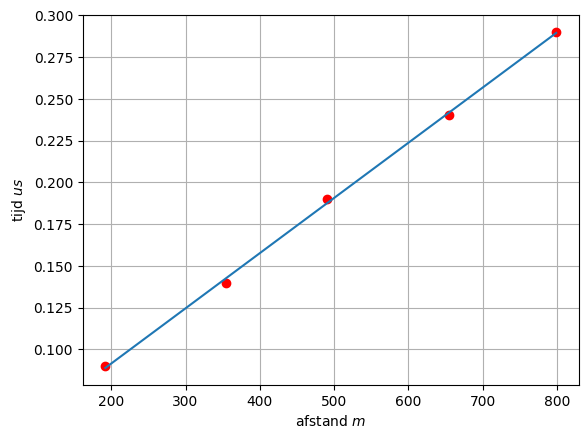

In [24]:
t = np.array([192, 355, 490, 654, 799])
x = (59 - np.array([50, 45, 40, 35, 30])) * 1e-2

def f(t, a, b):
    return a * t + b

def fit(t, x):
    #fit your function to the data
    popt, pcov = curve_fit(f, t, x, p0 = [330, 0])
    pcov = np.sqrt(np.diag(pcov))
    return popt

popt = fit(t, x)

# a is de geluidsnelheid m/us
#deze eenheden omdat het 
# b is de tijd die er nodig is als de sensor en meeter 0m uit elkaar zitten
a = popt[0]
b = popt[1]
print(a, b)

plt.figure()
plt.plot(t, x, 'ro')
plt.plot(t, f(t, *popt))
plt.xlabel(r"afstand $m$")
plt.ylabel(r"tijd $us$")

plt.grid()
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  40   0  30  43
1   0  30   0  20  44
2  40   0  30   0  44
3  30   0  20   0  44


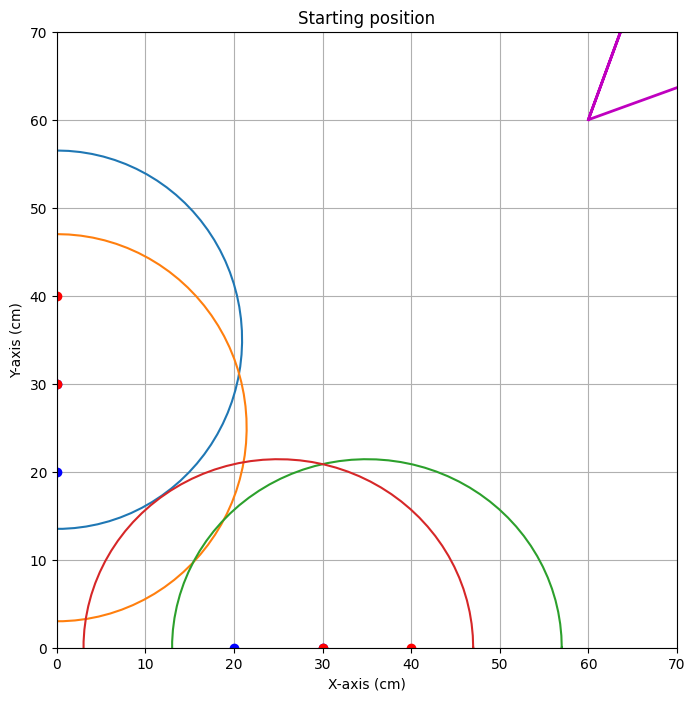


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=98.205


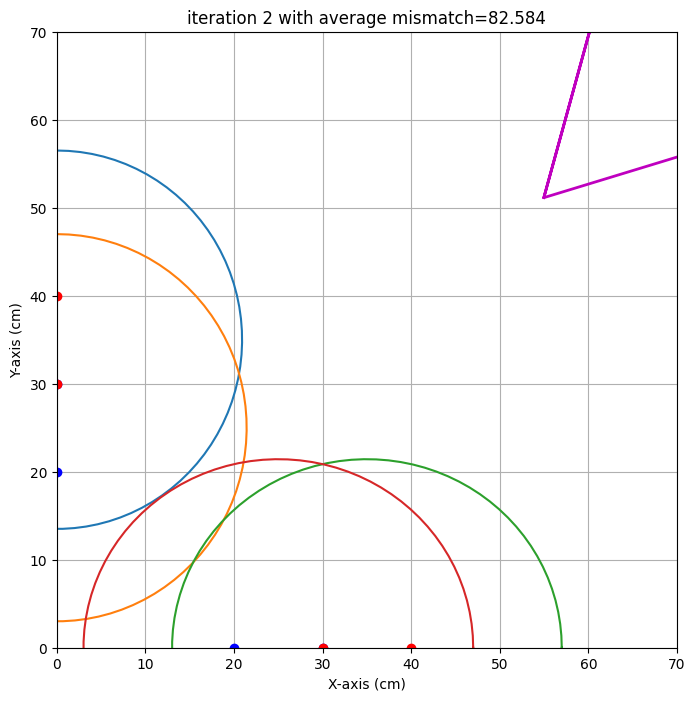

end iteration 2 with average mismatch=82.584


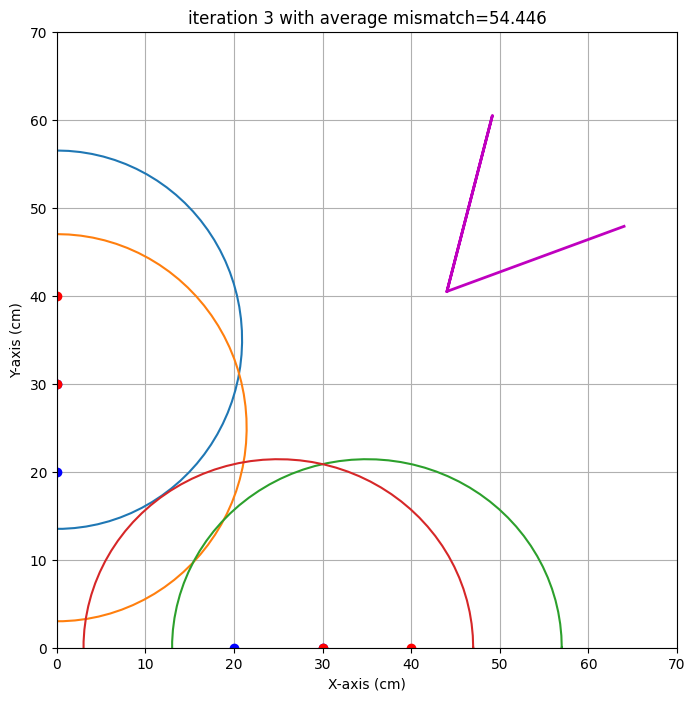

end iteration 3 with average mismatch=54.446


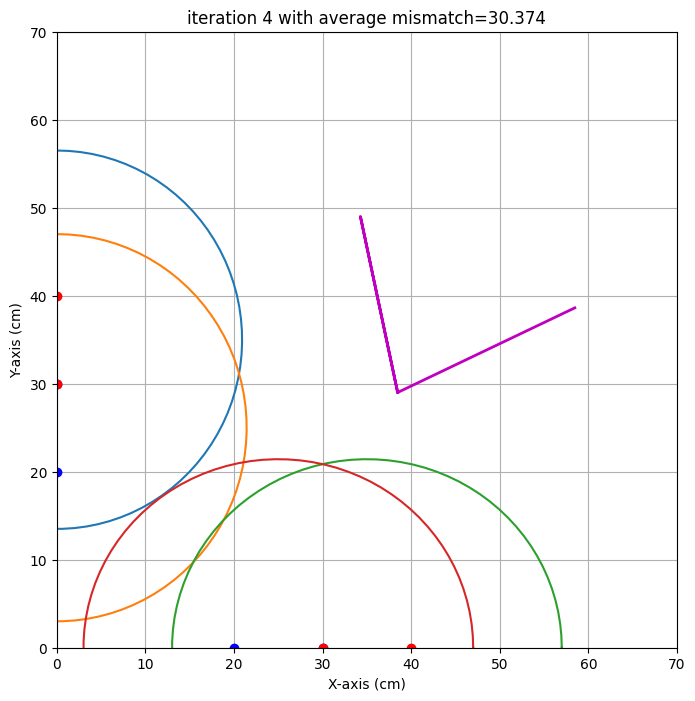

end iteration 4 with average mismatch=30.374


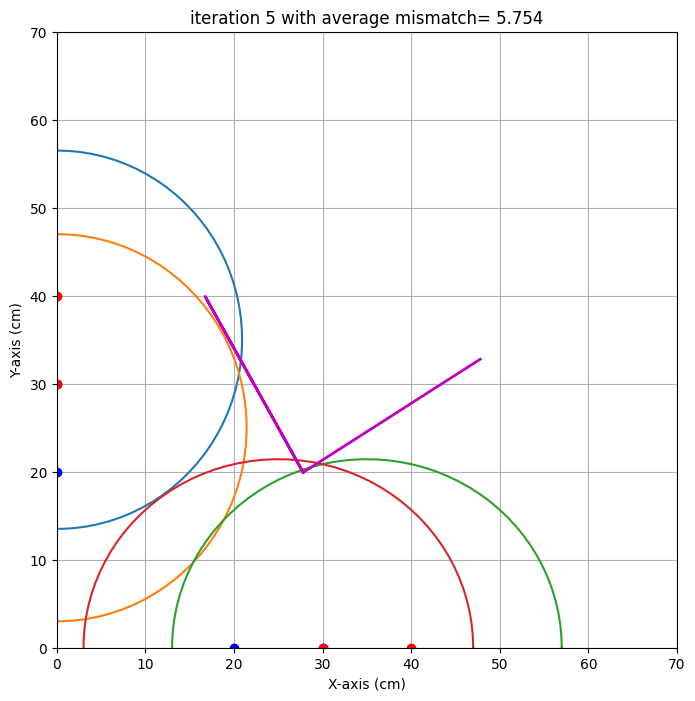

end iteration 5 with average mismatch= 5.754


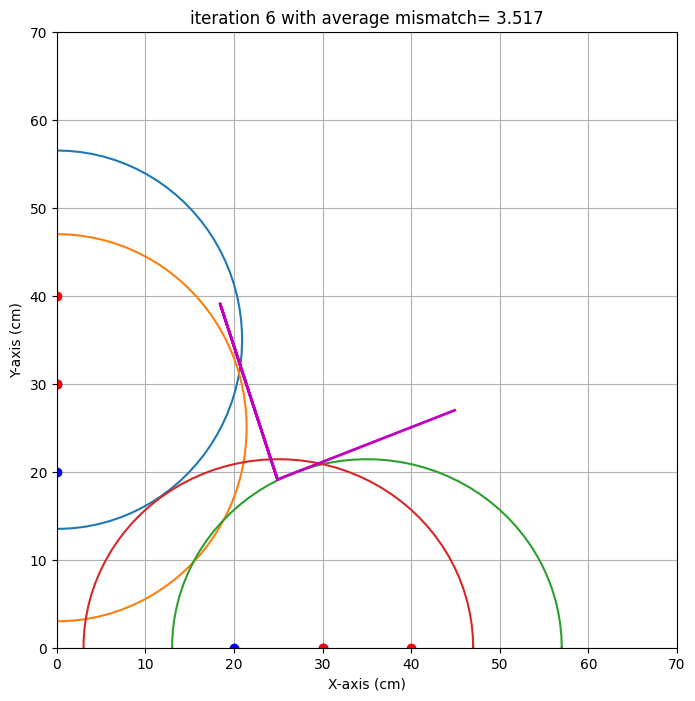

end iteration 6 with average mismatch= 3.517


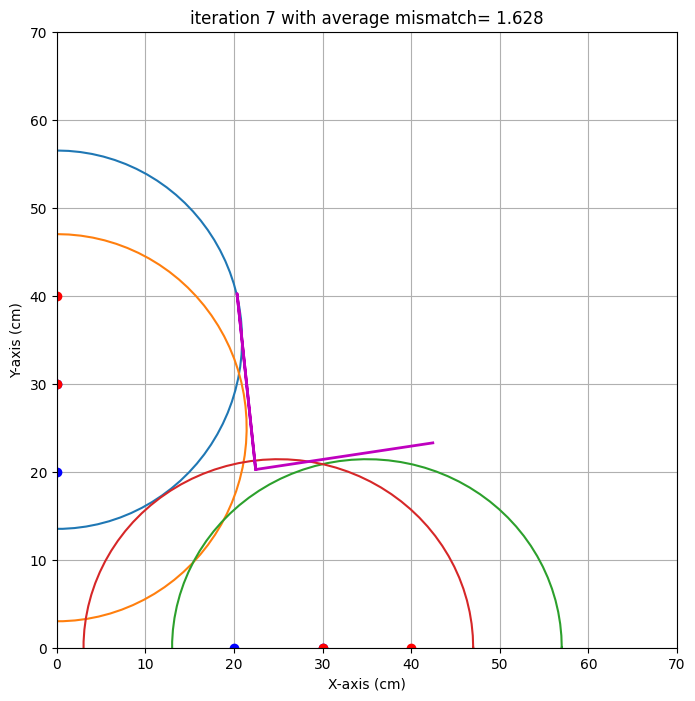

end iteration 7 with average mismatch= 1.628


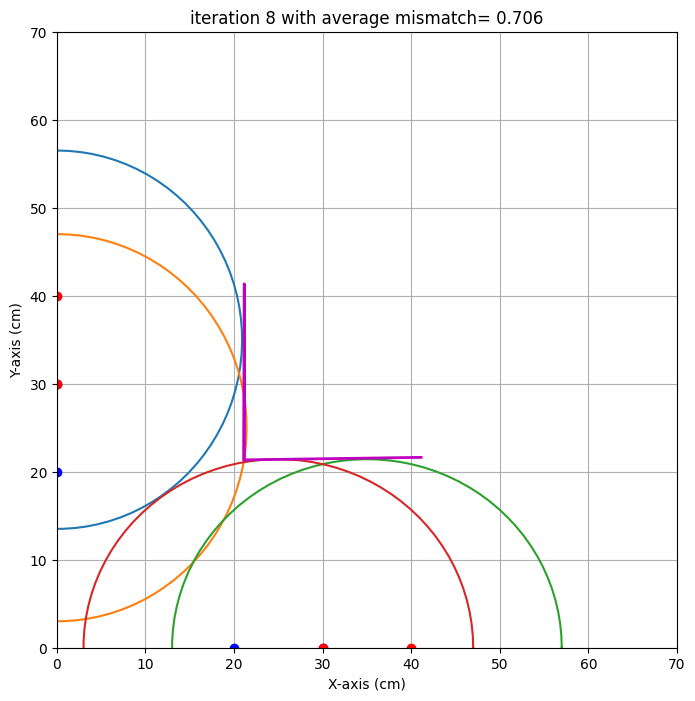

end iteration 8 with average mismatch= 0.706


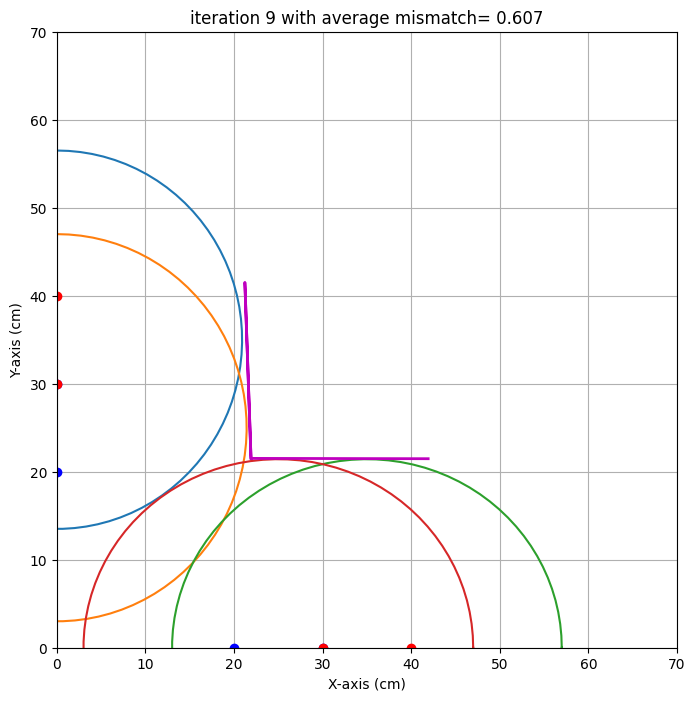

end iteration 9 with average mismatch= 0.607


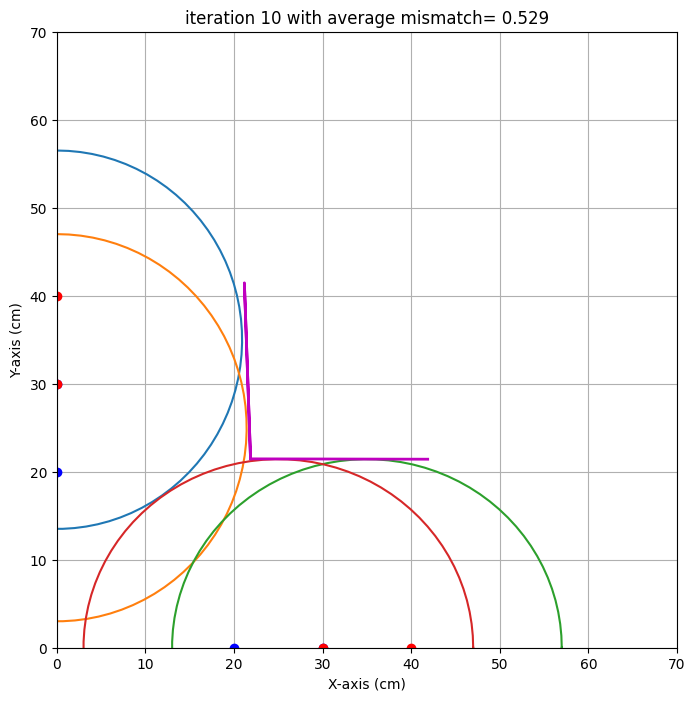

end iteration 10 with average mismatch= 0.529
end iteration 11 with average mismatch= 0.511
end iteration 12 with average mismatch= 0.499


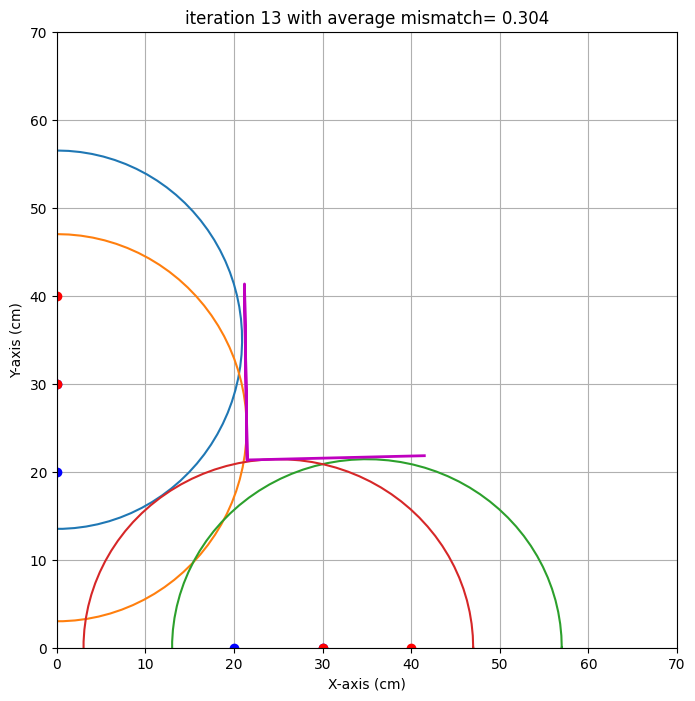

end iteration 13 with average mismatch= 0.304
end iteration 14 with average mismatch= 0.304
end iteration 15 with average mismatch= 0.304
end iteration 16 with average mismatch= 0.304
end iteration 17 with average mismatch= 0.304
end iteration 18 with average mismatch= 0.304
end iteration 19 with average mismatch= 0.304
end iteration 20 with average mismatch= 0.304
end iteration 21 with average mismatch= 0.304
end iteration 22 with average mismatch= 0.303


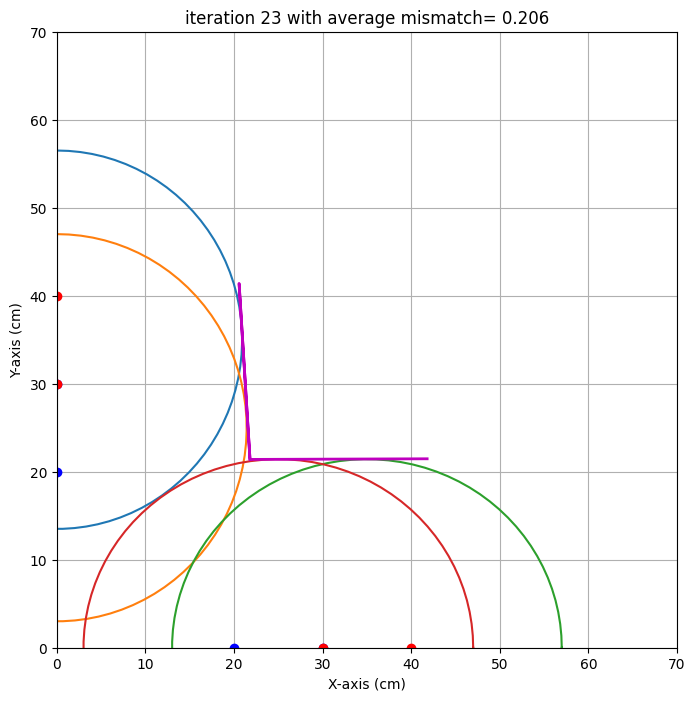

end iteration 23 with average mismatch= 0.206
end iteration 24 with average mismatch= 0.195
end iteration 25 with average mismatch= 0.195
end iteration 26 with average mismatch= 0.195
end iteration 27 with average mismatch= 0.195
end iteration 28 with average mismatch= 0.195
end iteration 29 with average mismatch= 0.195
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.195
###############################################################################
end of iteration  30
Best alpha=   0.22 with uncertainty=   0.11
Best beta =  -3.54 with uncertainty=   2.19
Best x0   =  21.79 with uncertainty=   0.16
Best y0   =  21.39 with uncertainty=   0.10
###############################################################################


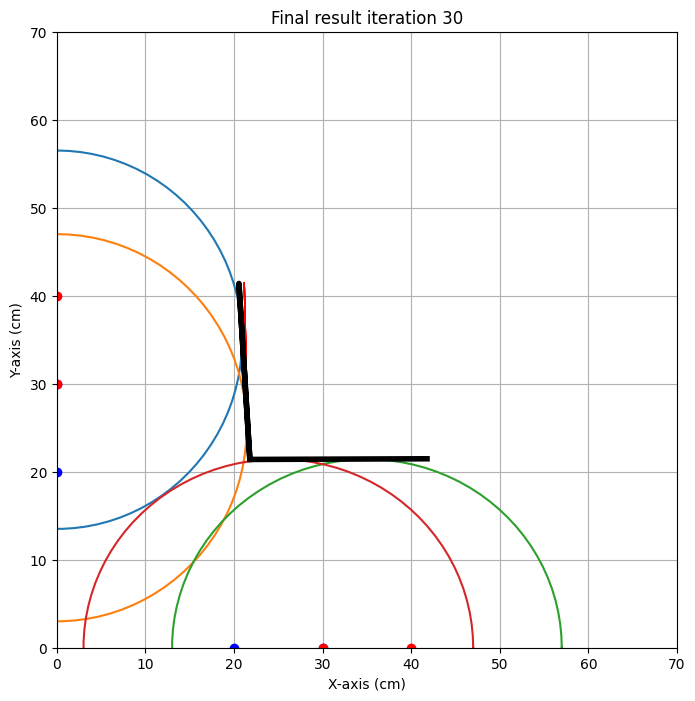

In [25]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30, 43],
    [0,30,0,20, 44],
#    [0,10,0,20, 244], hij ziet het papiertje niet maar de laptop
    [40,0,30,0, 44],
    [30,0,20,0, 44],
#    [10,0,20,0, 244], hij meet weer wat anders
#    [10,0,0,10, 256]  hij meet de hoek en niet een van de randen  
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [26]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.8 cm met een standaardafwijking van 0.2 cm 
y0: 21.4 cm met een standaardafwijking van 0.1 cm 
alpha: 0.2 graden met een standaardafwijking van 0.1 graad 
beta: -3.5 graden met een standaardafwijking van 2.2 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Bart]
1. start 

2. start met meetlocaties

eerste 4 "test locaties"
om te kijken waar hij ongeveer zit 

bron   , ontvanger
A [30, 0], [40, 0]
B [50, 0], [60, 0]
C [0, 30], [0, 40]
D [0, 50], [0, 60]

    # een meting is ongelding als deze groter dan 70cm of kleiner dan 20cm is

3. maak afhankelijk van welke metingen raakte een keuze voor de volgende metingen

	a (alle 4 raakte)
	 dit betekend dat hij ongeveer in het midden staat en er zijn in principe geen verdere metingen nodig om alles te bepalen


	b (2 raakte: 1 op elke as)
	 dit betekend dat hij in een van de 4 kwadranten zit
	doe 2 extra metingen (1 per as) en verplaats hiervoor alles met 5 richting 0
	in het geval dat een (of allebei)van deze waarde(s) niet geldig zijn verplaats je ze t.o.v hun beginposities 5 van 0 af
	nu zou je 4 goede metingen moeten hebben kan je alles bepalen 


	c (3 raken)
	 dit betekend dat hij in de buurt van een van de randen zit
	doe 1 extra meting op de as waarvan je maar een geldige metingen had en verplaats hiervoor alles met 5 richting 0
	in het geval dat deze waarde niet geldig IS verplaats je hem t.o.v zijn beginposities 5 van 0 af
	nu zou je 4 goede metingen moeten hebben kan je alles bepalen 

	d (1 raakt of 2 op dezelfde as)
	 dit betekend dat de hoek tussen het karton redelijk klein is
	 dit betekend dat hij zich bevind in een van de kolommen tussen of buiten de meetputen A,B,C,D 
	 afhankelijk van op welke as je de metingen had

	als je maar 1 raak is:
		voor de as van de waarde die wel raakte:
		doe 1 extra meting op de as waarvan je maar een geldige metingen had en verplaats hiervoor alles met 5 richting 0
		in het geval dat deze waarde niet geldig IS verplaats je hem t.o.v zijn beginposities 5 van 0 af
		nu zou je 4 goede metingen moeten hebben kan je alles bepalen


	voor de as waar je geen waardes had:
		probeer een van de volgende meetpunten afhankelijk van de as:
		x as
		[20,0],[30,0]
		[40,0],[50,0]
		[60,0],[70,0]
		y as
		[0,20],[0,30]
		[0,40],[0,50]
		[0,60],[0,70]
		
		als deze een raak is:
		doe 1 extra meting en verplaats alles met 5 richting 0
		in het geval dat deze waarde niet geldig is verplaats je hem t.o.v zijn beginposities 5 van 0 af
		nu zou je 4 goede metingen moeten hebben kan je alles bepalen

		als hij mis was:
		kies je een nieuw meetpunt tot i wel raak is

#### algoritme [Zahra]
<img src="Zahra2.jpeg" width="400">

#### algoritme [Shahraan]
<img src="Shahraan2.jpeg" width="400">

## Opdracht 6: Test iteratie 0.

In [27]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 33,
           'y0': -5,
           'alpha' :23.5,
           'beta' :33
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Zahra' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
#    [ 0, 10, 0, 20, 240], ongeldige meting
    [ 0, 30, 0, 20, 65],
    [ 0, 40, 0, 30, 65],
    [ 0, 50, 0, 40, 64],
#    [ 0, 60, 0, 50, 240], ongeldige meting
#    [ 0, 70, 0, 60, 240], ongeldige meting
#    [ 10, 0, 20, 0, 240], ongeldige meting
#    [ 30, 0, 20, 0, 240], ongeldige meting
#    [ 40, 0, 30, 0, 240], ongeldige meting
    [ 50, 0, 40, 0, 63],
    [ 60, 0, 50, 0, 68],
    [ 70, 0, 60, 0, 74]
    ]),
       'Bart' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
#    [ 30, 0, 40, 0, 240], ongeldige meting
    [ 50, 0, 60, 0, 67],
    [ 0, 30, 0, 40, 65],
#    [ 0, 50, 0, 60, 240], ongeldige meting
#    [ 25, 0, 35, 0, 240], ongeldige meting
    [ 35, 0, 45, 0, 58], # was iets bijgedraaid
    [ 0, 25, 0, 35, 68]
    ])
      }

## Opdracht 7: Evaluatie.

Bart
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  50   0  60   0  67
1   0  30   0  40  65
2  35   0  45   0  58
3   0  25   0  35  68


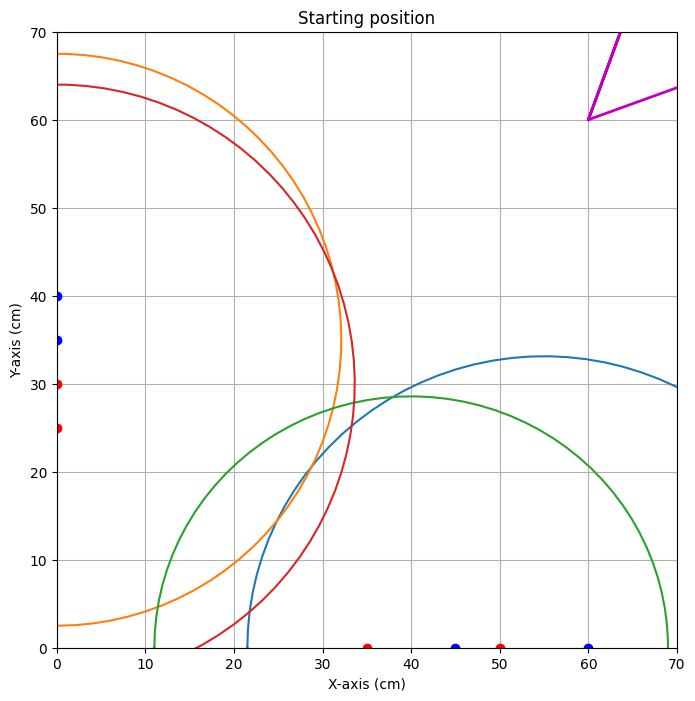


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=70.801


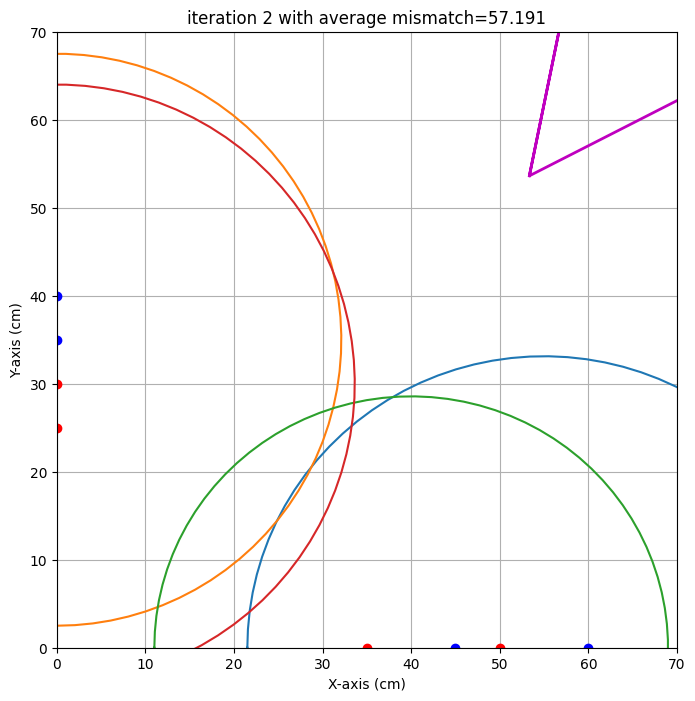

end iteration 2 with average mismatch=57.191


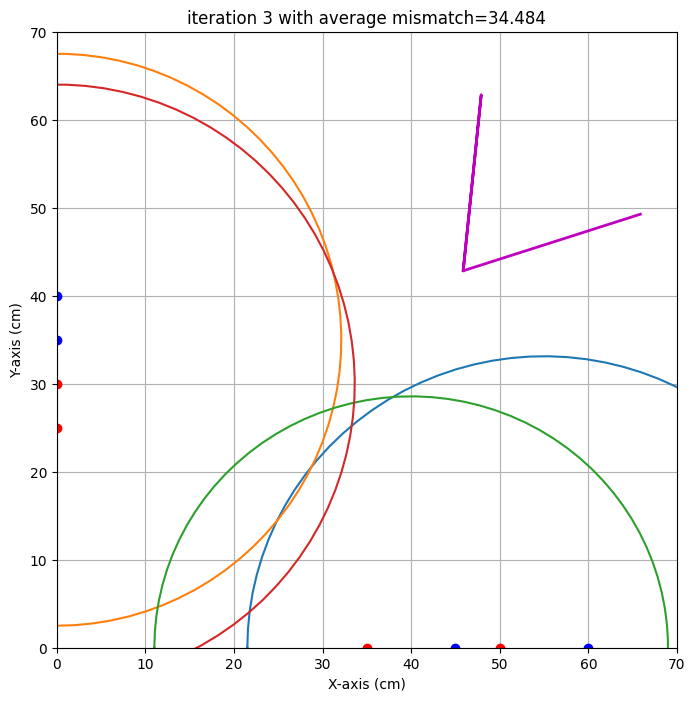

end iteration 3 with average mismatch=34.484


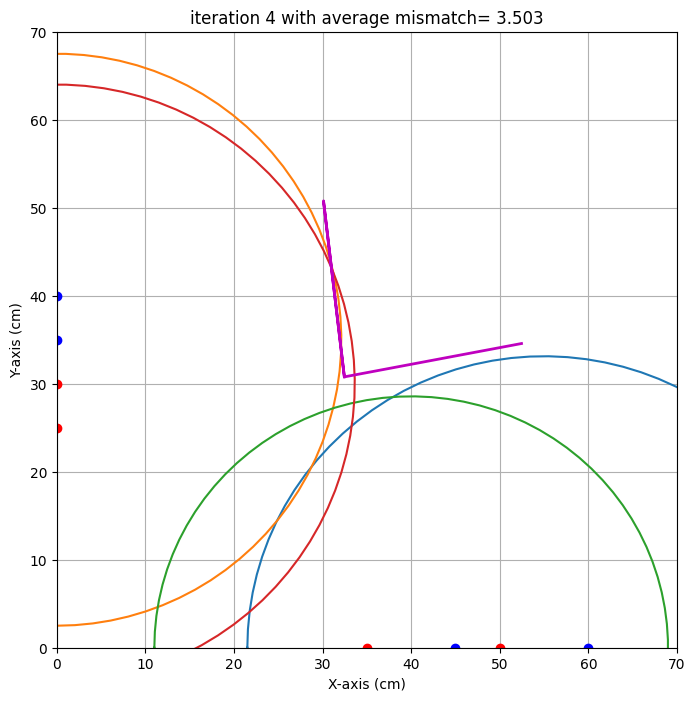

end iteration 4 with average mismatch= 3.503


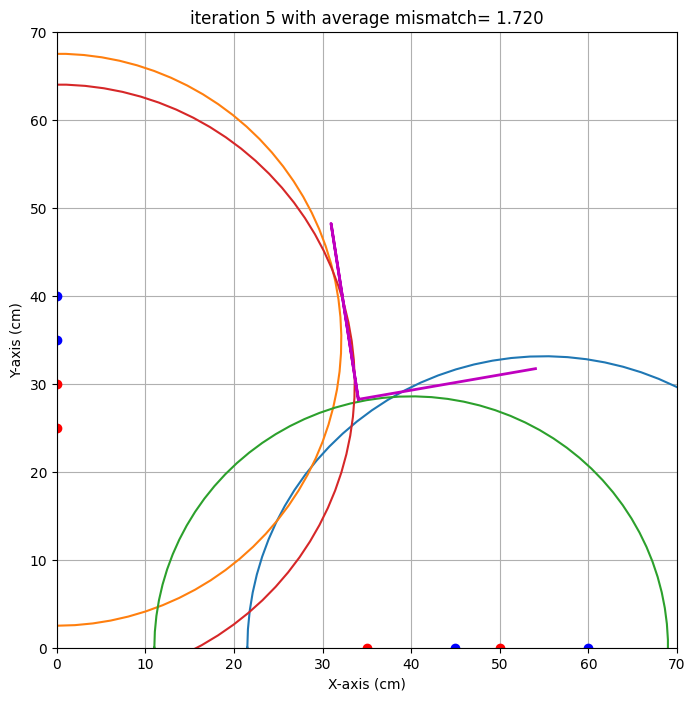

end iteration 5 with average mismatch= 1.720
end iteration 6 with average mismatch= 1.678
end iteration 7 with average mismatch= 1.541
end iteration 8 with average mismatch= 1.451
end iteration 9 with average mismatch= 1.448
end iteration 10 with average mismatch= 1.448
end iteration 11 with average mismatch= 1.448
end iteration 12 with average mismatch= 1.448
end iteration 13 with average mismatch= 1.448
end iteration 14 with average mismatch= 1.448
end iteration 15 with average mismatch= 1.392
end iteration 16 with average mismatch= 1.355
end iteration 17 with average mismatch= 1.347
end iteration 18 with average mismatch= 1.346
end iteration 19 with average mismatch= 1.346
end iteration 20 with average mismatch= 1.346
end iteration 21 with average mismatch= 1.346
end iteration 22 with average mismatch= 1.346
end iteration 23 with average mismatch= 1.346
end iteration 24 with average mismatch= 1.346
end iteration 25 with average mismatch= 1.346
end iteration 26 with average mismatch=

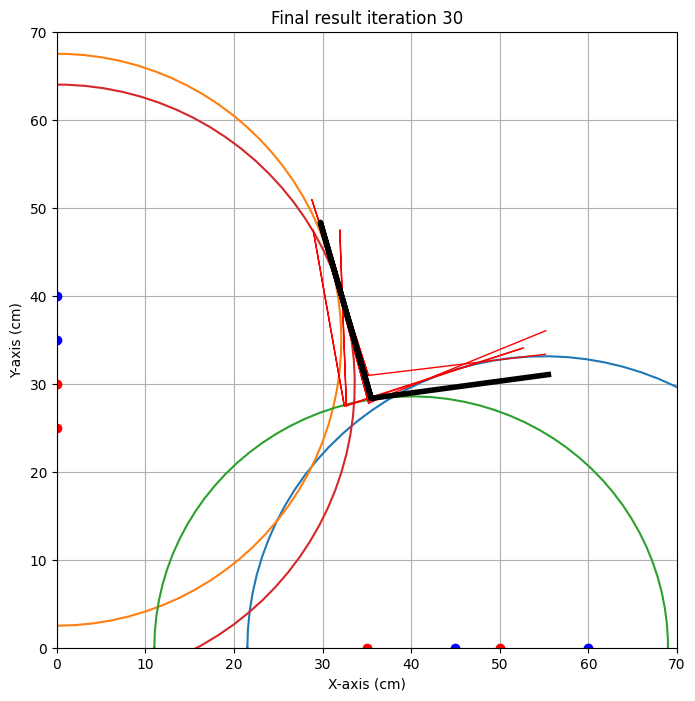

{'alpha': np.float64(7.68630405610384), 'alpha_eps': np.float64(14.657202097317573), 'beta': np.float64(-16.017822675783602), 'beta_eps': np.float64(13.876041851309688), 'x0': np.float64(35.48841532733439), 'x0_eps': np.float64(3.038551553066725), 'y0': np.float64(28.34010374871839), 'y0_eps': np.float64(2.601000886638829)}
Zahra
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  30   0  20  65
1   0  40   0  30  65
2   0  50   0  40  64
3  50   0  40   0  63
4  60   0  50   0  68
5  70   0  60   0  74


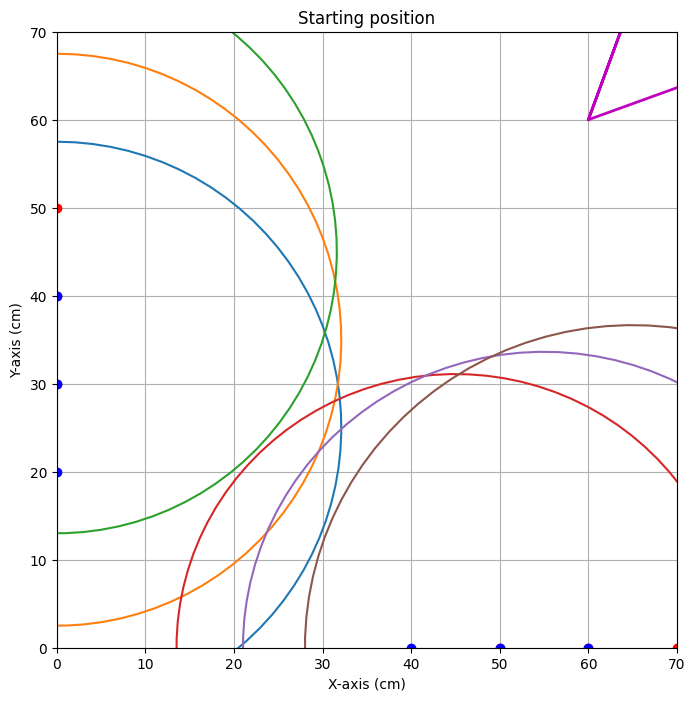


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=67.011


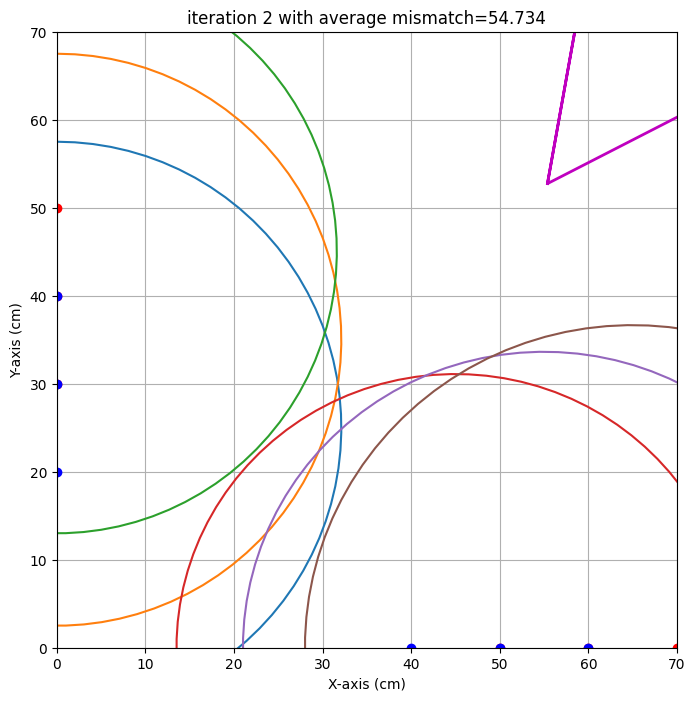

end iteration 2 with average mismatch=54.734


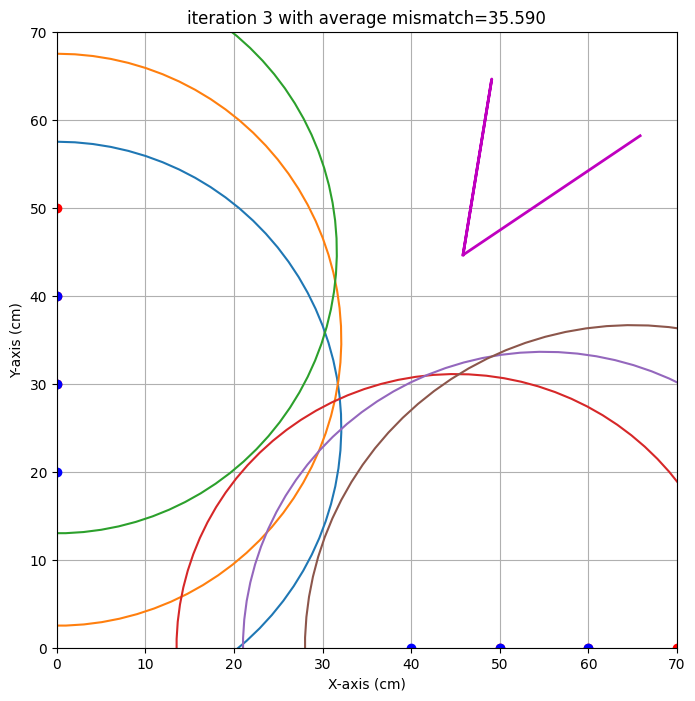

end iteration 3 with average mismatch=35.590


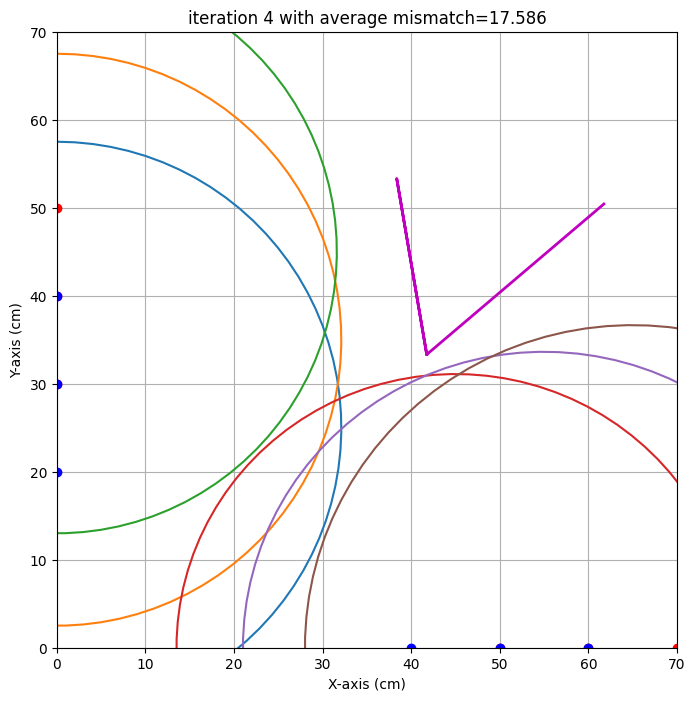

end iteration 4 with average mismatch=17.586


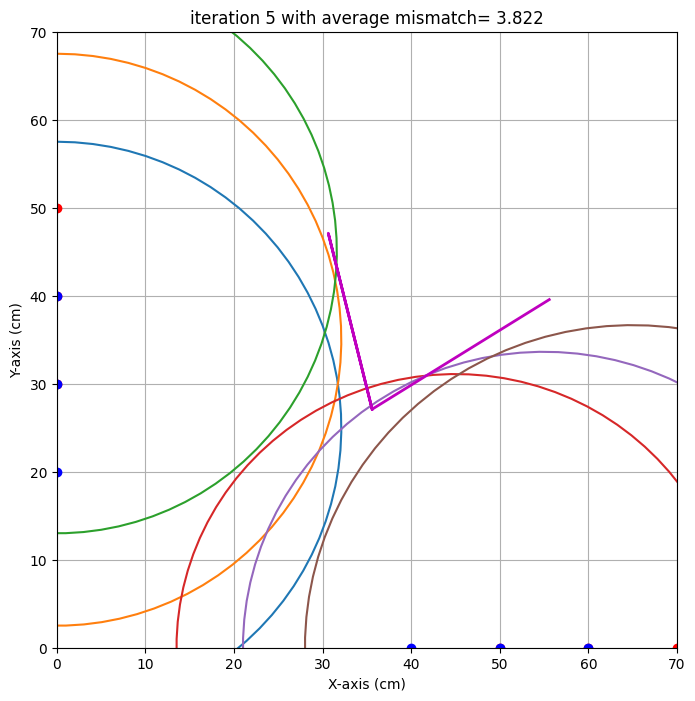

end iteration 5 with average mismatch= 3.822


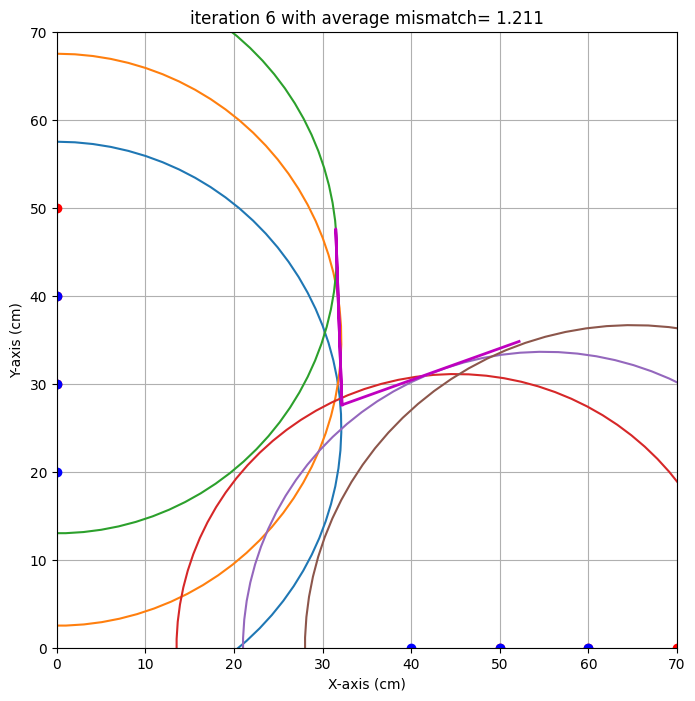

end iteration 6 with average mismatch= 1.211


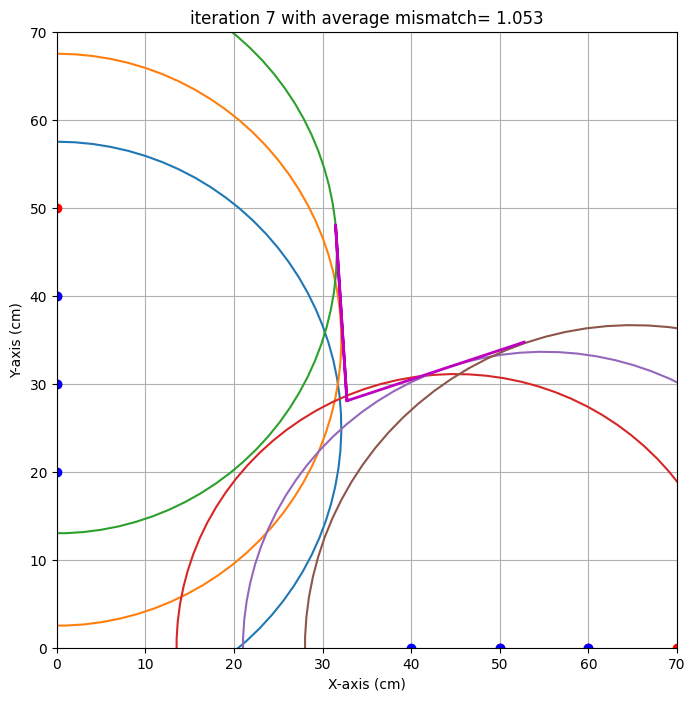

end iteration 7 with average mismatch= 1.053


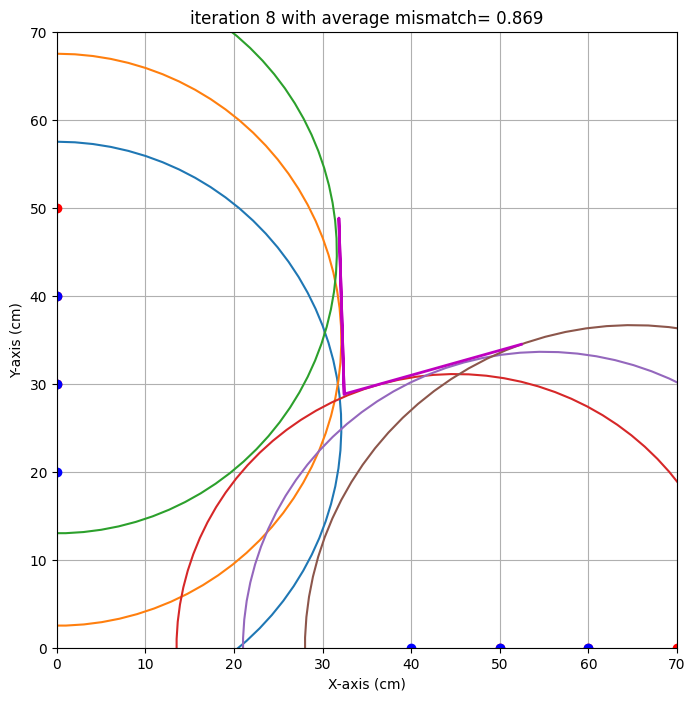

end iteration 8 with average mismatch= 0.869
end iteration 9 with average mismatch= 0.803
end iteration 10 with average mismatch= 0.762
end iteration 11 with average mismatch= 0.749
end iteration 12 with average mismatch= 0.749
end iteration 13 with average mismatch= 0.749
end iteration 14 with average mismatch= 0.749
end iteration 15 with average mismatch= 0.749
end iteration 16 with average mismatch= 0.749
end iteration 17 with average mismatch= 0.749
end iteration 18 with average mismatch= 0.749
end iteration 19 with average mismatch= 0.749
end iteration 20 with average mismatch= 0.749
end iteration 21 with average mismatch= 0.749
end iteration 22 with average mismatch= 0.749
end iteration 23 with average mismatch= 0.749
end iteration 24 with average mismatch= 0.749
end iteration 25 with average mismatch= 0.749
end iteration 26 with average mismatch= 0.749
end iteration 27 with average mismatch= 0.749
end iteration 28 with average mismatch= 0.749
end iteration 29 with average mismat

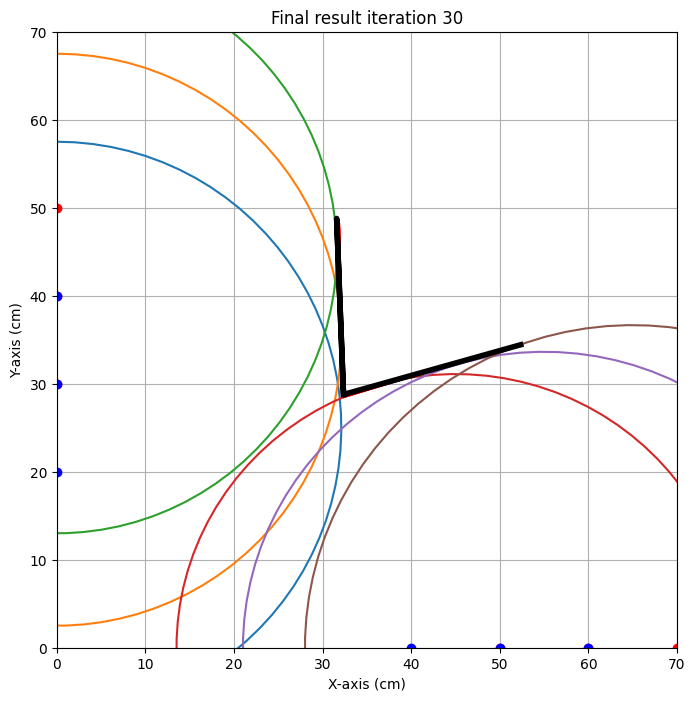

{'alpha': np.float64(15.779741139840345), 'alpha_eps': np.float64(1.2191213217930983), 'beta': np.float64(-2.226340875138231), 'beta_eps': np.float64(0.8055663422152932), 'x0': np.float64(32.36082640147783), 'x0_eps': np.float64(0.01930876283110905), 'y0': np.float64(28.776635816195288), 'y0_eps': np.float64(0.33105019245668643)}


In [28]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames[:-1]:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [29]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames[:-1]:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Bart 
x0 target is : 33.0. Gevonden waarde: 35.5 cm met een standaardafwijking van 3.0 cm 
y0 target is : -5.0. Gevonden waarde: 28.3 cm met een standaardafwijking van 2.6 cm 
alpha target is : 23.5. Gevonden waarde: 7.7 graden met een standaardafwijking van 14.7 graad 
beta target is : 33.0. Gevonden waarde: -16.0 graden met een standaardafwijking van 13.9 graad 

Zahra 
x0 target is : 33.0. Gevonden waarde: 32.4 cm met een standaardafwijking van 0.0 cm 
y0 target is : -5.0. Gevonden waarde: 28.8 cm met een standaardafwijking van 0.3 cm 
alpha target is : 23.5. Gevonden waarde: 15.8 graden met een standaardafwijking van 1.2 graad 
beta target is : 33.0. Gevonden waarde: -2.2 graden met een standaardafwijking van 0.8 graad 



## Opdracht 8: Iteratie1+.V 14:50
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](ideratie_1.png)


## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  30   0  40   0  91
1  50   0  60   0  89
2   0  50   0  60  72
3   0  42   0  57  77


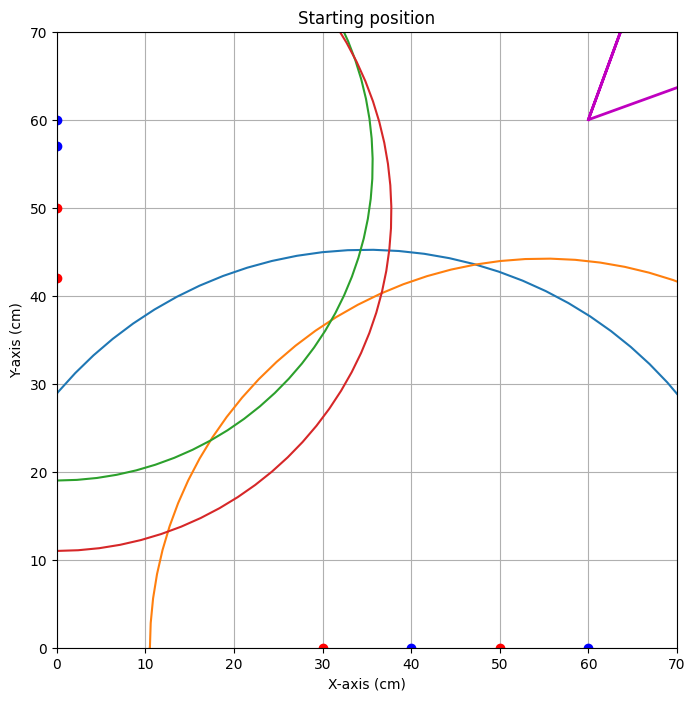


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.343


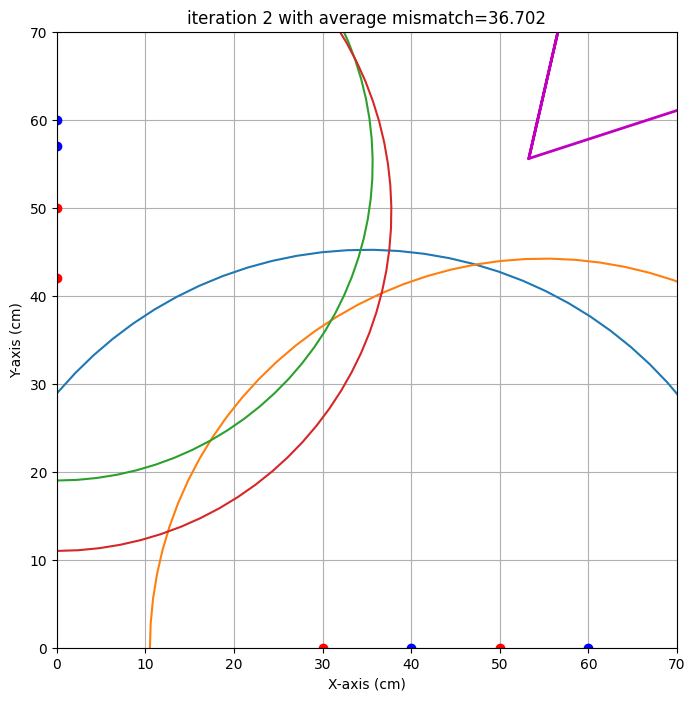

end iteration 2 with average mismatch=36.702


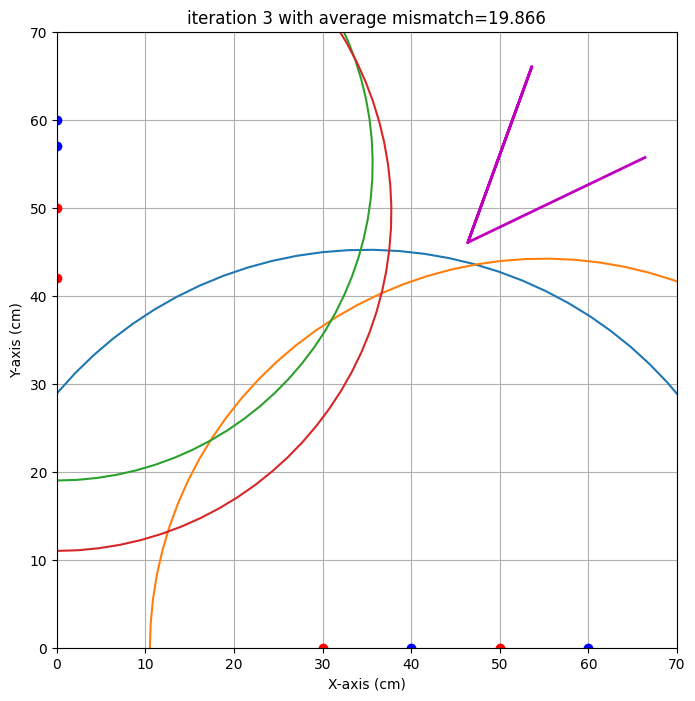

end iteration 3 with average mismatch=19.866


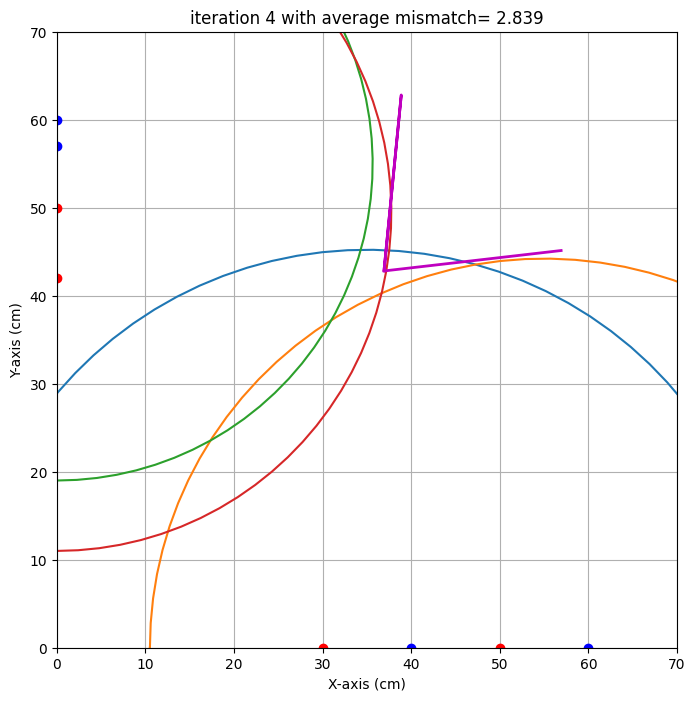

end iteration 4 with average mismatch= 2.839


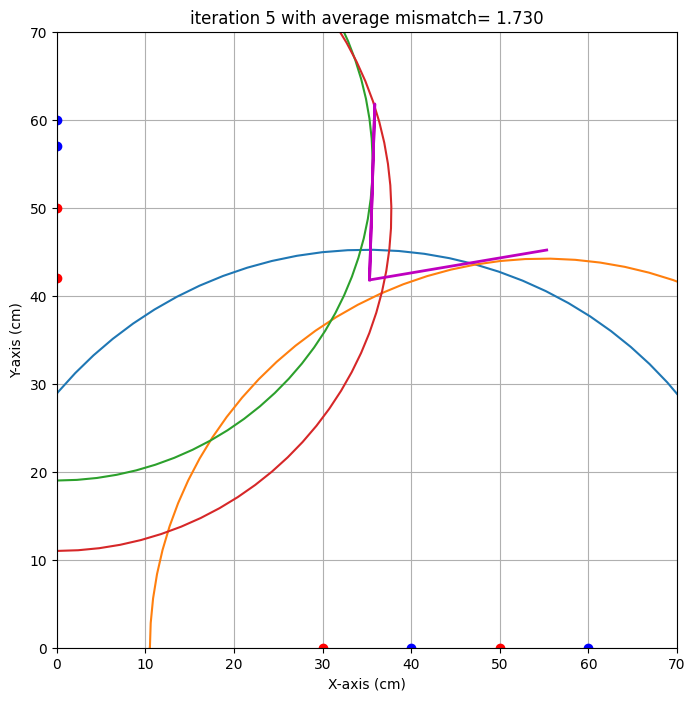

end iteration 5 with average mismatch= 1.730
end iteration 6 with average mismatch= 1.711
end iteration 7 with average mismatch= 1.706
end iteration 8 with average mismatch= 1.579


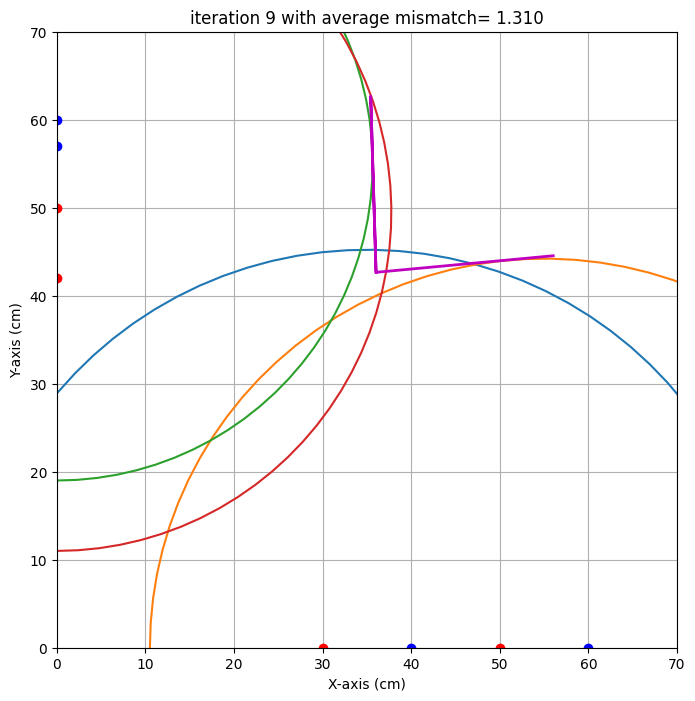

end iteration 9 with average mismatch= 1.310
end iteration 10 with average mismatch= 1.308
end iteration 11 with average mismatch= 1.242
end iteration 12 with average mismatch= 1.198
end iteration 13 with average mismatch= 1.197
end iteration 14 with average mismatch= 1.138
end iteration 15 with average mismatch= 1.137
end iteration 16 with average mismatch= 1.116


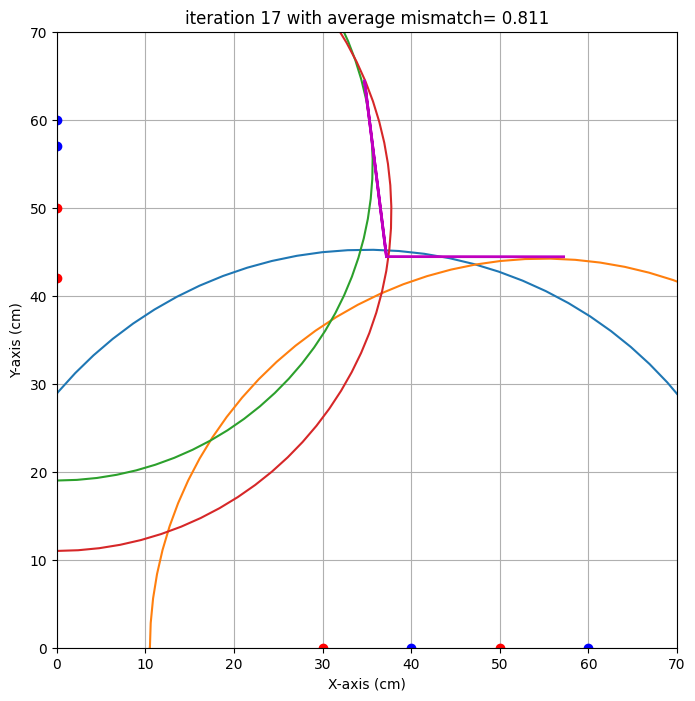

end iteration 17 with average mismatch= 0.811
end iteration 18 with average mismatch= 0.752
end iteration 19 with average mismatch= 0.693
end iteration 20 with average mismatch= 0.633
end iteration 21 with average mismatch= 0.613
end iteration 22 with average mismatch= 0.612
end iteration 23 with average mismatch= 0.612
end iteration 24 with average mismatch= 0.612
end iteration 25 with average mismatch= 0.595
end iteration 26 with average mismatch= 0.595


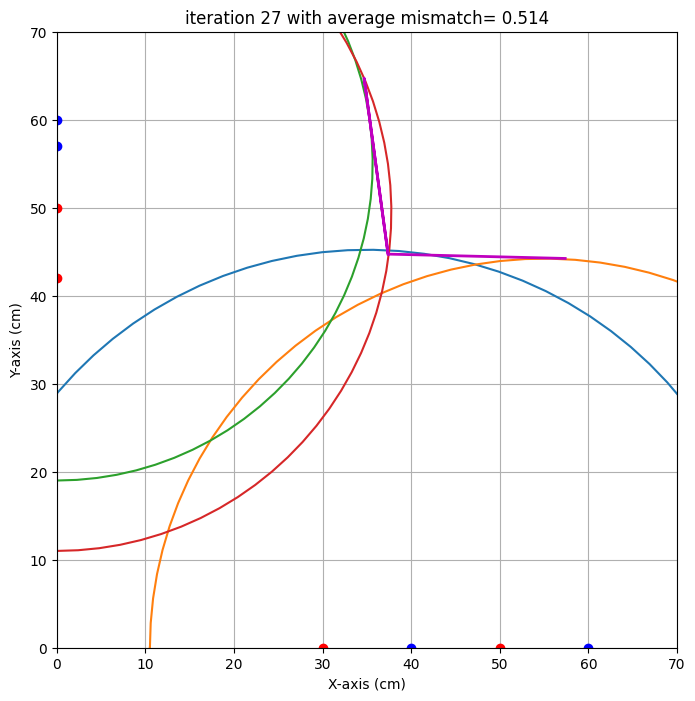

end iteration 27 with average mismatch= 0.514
end iteration 28 with average mismatch= 0.513
end iteration 29 with average mismatch= 0.513
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.513
###############################################################################
end of iteration  30
Best alpha=  -1.42 with uncertainty=   1.09
Best beta =  -7.71 with uncertainty=   1.89
Best x0   =  37.37 with uncertainty=   0.46
Best y0   =  44.73 with uncertainty=   0.42
###############################################################################


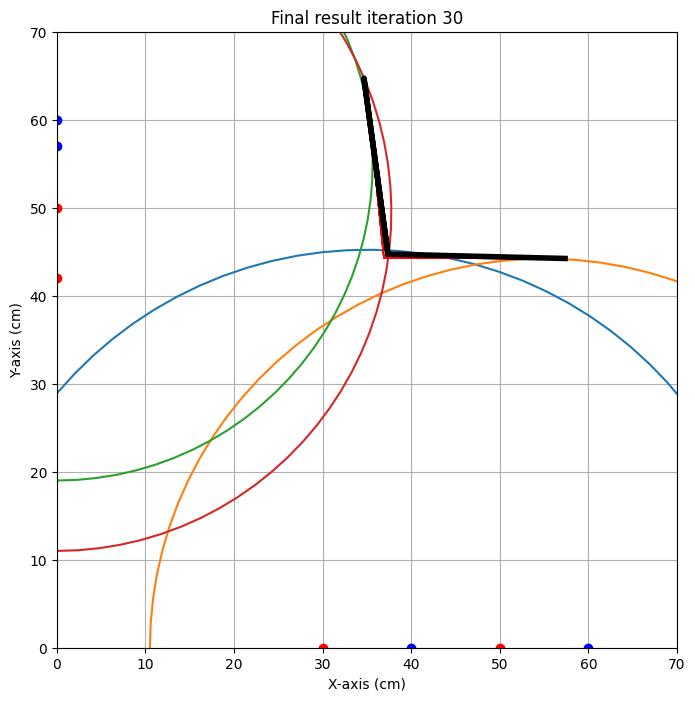

{'alpha': np.float64(-1.4173938957977754), 'alpha_eps': np.float64(1.085151087251316), 'beta': np.float64(-7.71478594351335), 'beta_eps': np.float64(1.8899020878252433), 'x0': np.float64(37.37379406136957), 'x0_eps': np.float64(0.4566130163093405), 'y0': np.float64(44.72877697686757), 'y0_eps': np.float64(0.41632228026267626)}
locatie 1 
x0 target is : 33.4. Gevonden waarde: 37.4 cm met een standaardafwijking van 0.5 cm 
y0 target is : 43.9. Gevonden waarde: 44.7 cm met een standaardafwijking van 0.4 cm 
alpha target is : 18.0. Gevonden waarde: -1.4 graden met een standaardafwijking van 1.1 graad 
beta target is : 0.0. Gevonden waarde: -7.7 graden met een standaardafwijking van 1.9 graad 



In [30]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 33.4,
                    'y0': 43.9,
                    'alpha' : 18,
                    'beta' : 0},
            }


# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [ 30, 0, 40, 0, 91],
    [ 50, 0, 60, 0, 89],
#    [ 0, 30, 0, 40, 240], ongeldige meting
    [ 0, 50, 0, 60, 72],
#    [ 0, 40, 0, 50, ]
    [ 0, 42, 0, 57, 77] #afgeweken val algoritme om hem te verbeteren 
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

# iteratie 2

Figuur: ![Alt](ideratie_2.png)

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  30   0  45   0  59
1   0  30   0  45  54
2  40   0  55   0  60
3   0  40   0  55  57


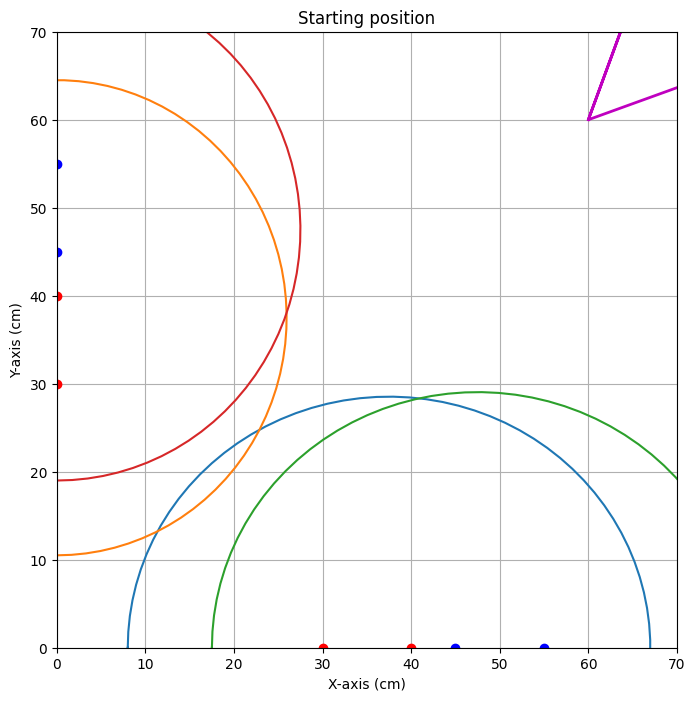


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=75.277


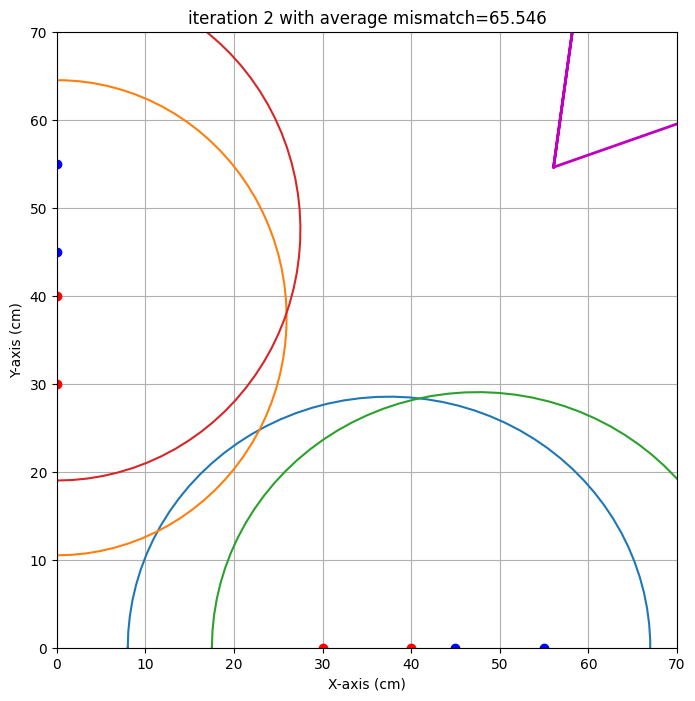

end iteration 2 with average mismatch=65.546


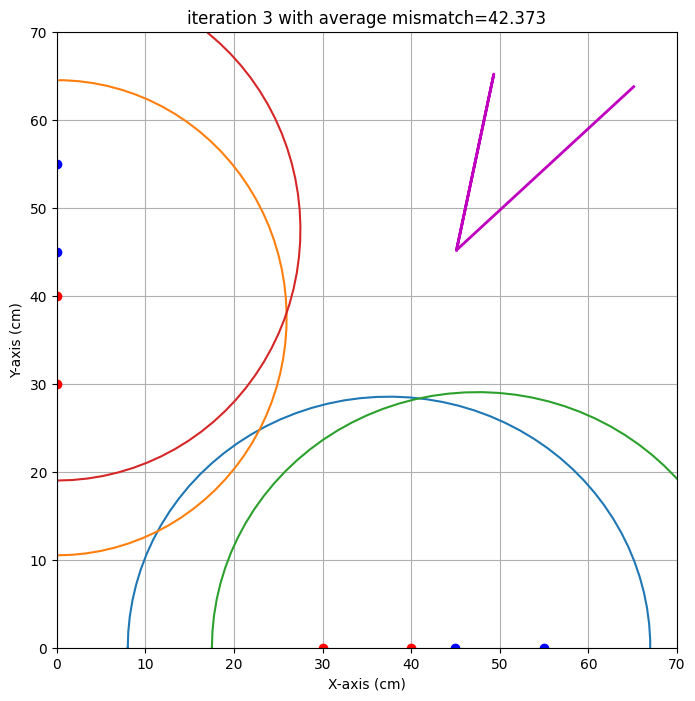

end iteration 3 with average mismatch=42.373


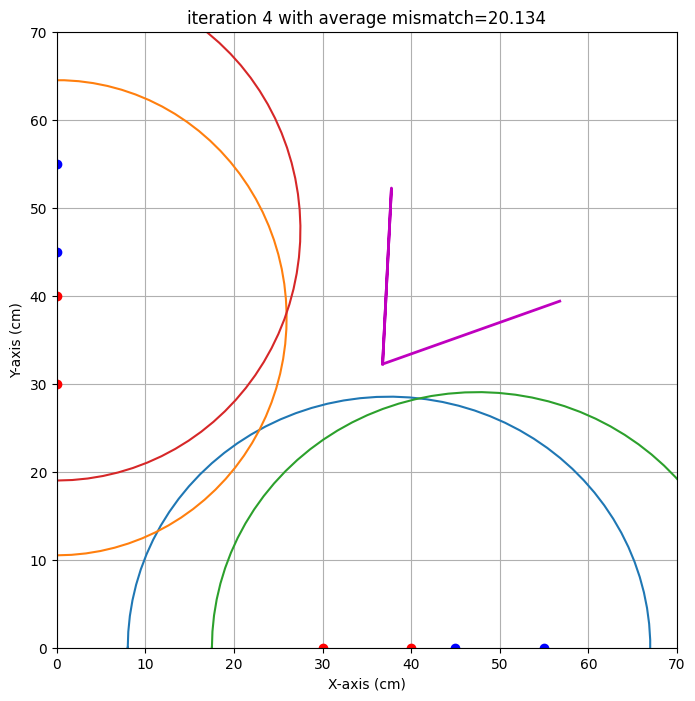

end iteration 4 with average mismatch=20.134


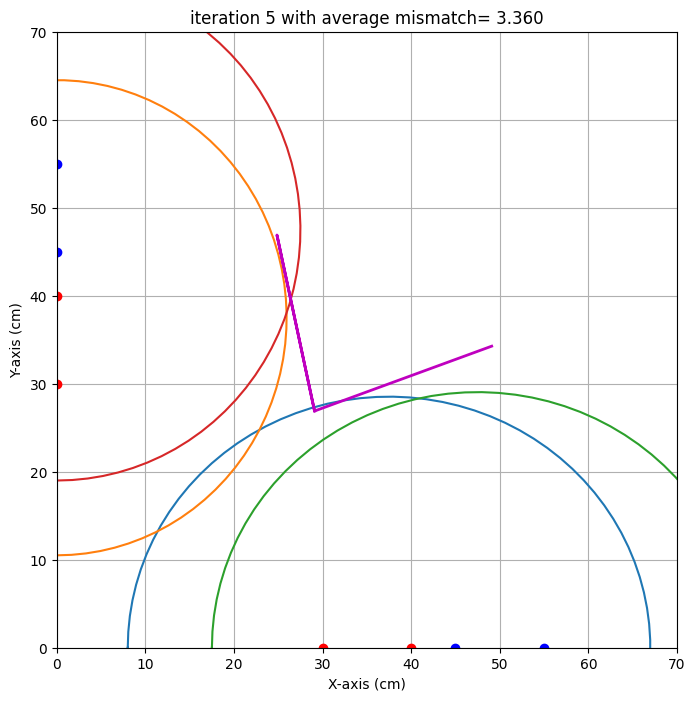

end iteration 5 with average mismatch= 3.360


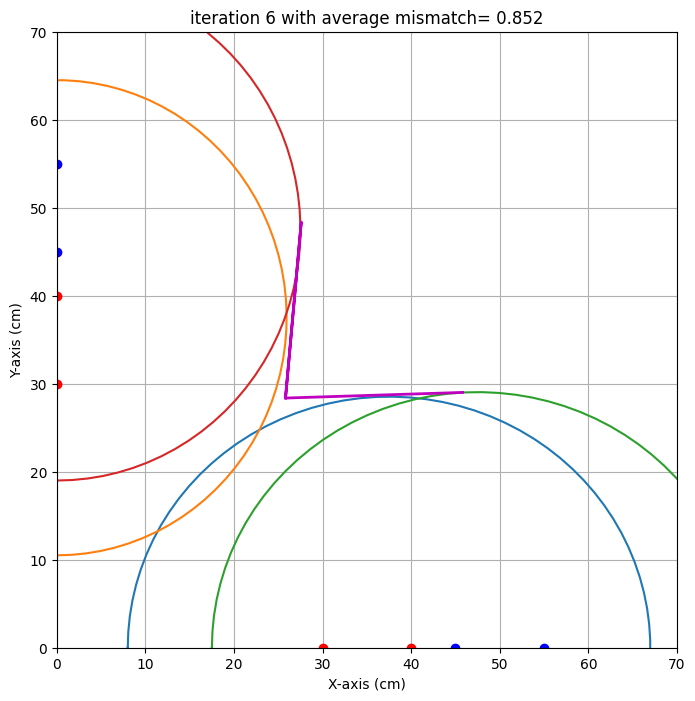

end iteration 6 with average mismatch= 0.852


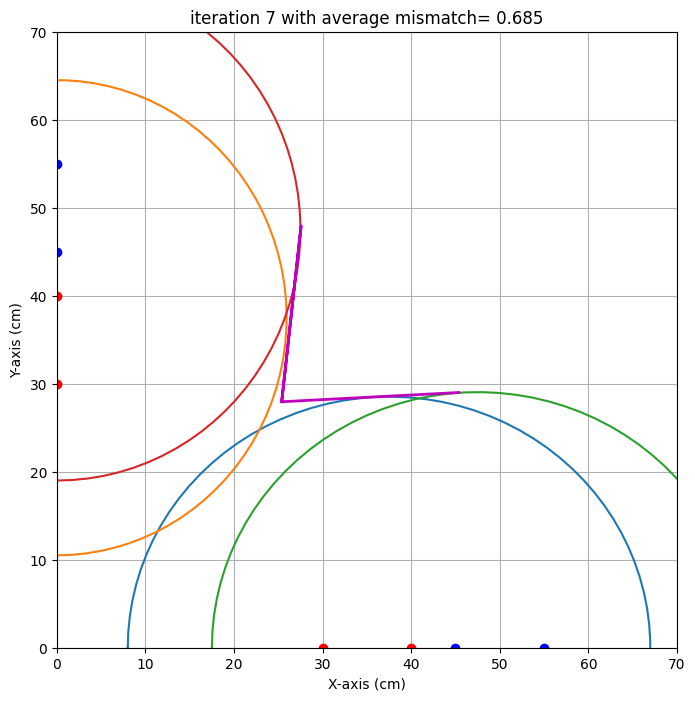

end iteration 7 with average mismatch= 0.685


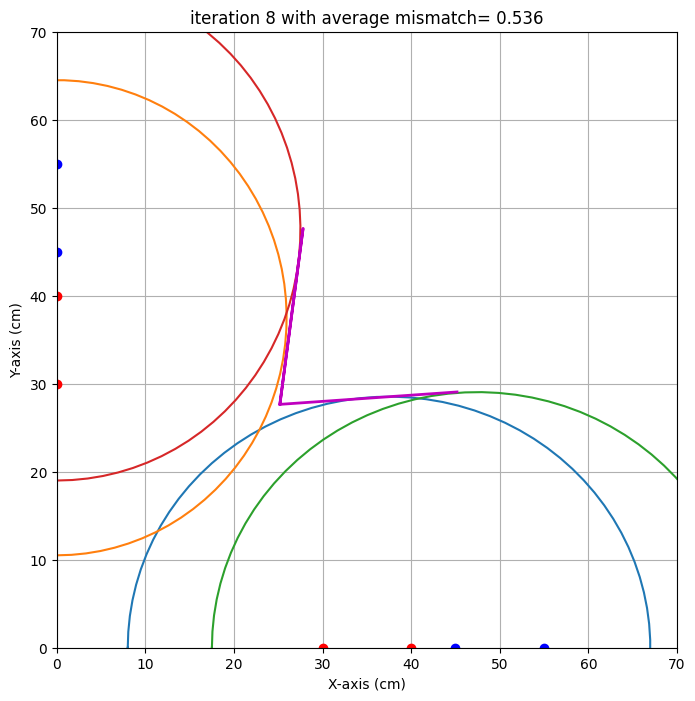

end iteration 8 with average mismatch= 0.536


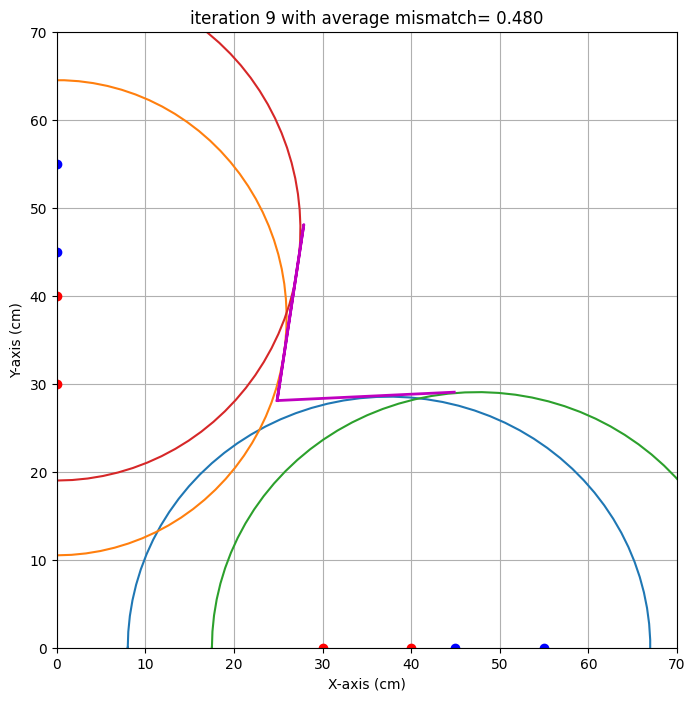

end iteration 9 with average mismatch= 0.480


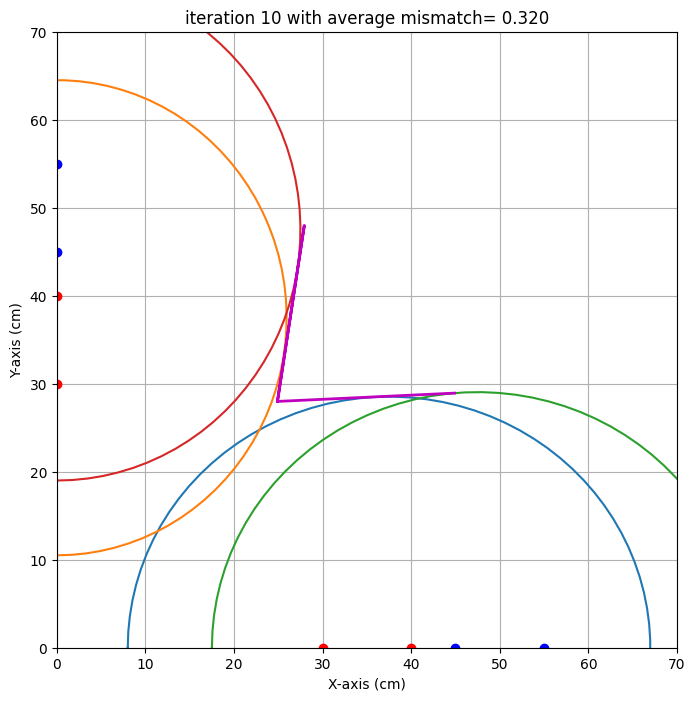

end iteration 10 with average mismatch= 0.320
end iteration 11 with average mismatch= 0.311
end iteration 12 with average mismatch= 0.311
end iteration 13 with average mismatch= 0.311
end iteration 14 with average mismatch= 0.311
end iteration 15 with average mismatch= 0.311
end iteration 16 with average mismatch= 0.311
end iteration 17 with average mismatch= 0.311
end iteration 18 with average mismatch= 0.311
end iteration 19 with average mismatch= 0.311
end iteration 20 with average mismatch= 0.311
end iteration 21 with average mismatch= 0.311
end iteration 22 with average mismatch= 0.311
end iteration 23 with average mismatch= 0.311
end iteration 24 with average mismatch= 0.311
end iteration 25 with average mismatch= 0.311
end iteration 26 with average mismatch= 0.311
end iteration 27 with average mismatch= 0.311
end iteration 28 with average mismatch= 0.311
end iteration 29 with average mismatch= 0.311
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

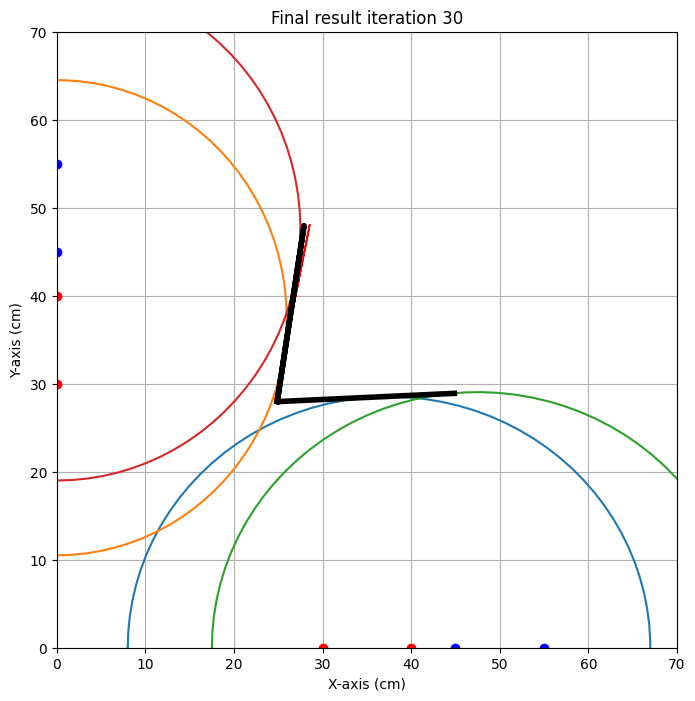

{'alpha': np.float64(2.6884865231468718), 'alpha_eps': np.float64(0.07238823766462232), 'beta': np.float64(8.61225424658285), 'beta_eps': np.float64(2.471431273153666), 'x0': np.float64(24.87257615478247), 'x0_eps': np.float64(0.24957419473751585), 'y0': np.float64(27.967132981469142), 'y0_eps': np.float64(0.0946463034029037)}
locatie 1 
x0 target is : 25.7. Gevonden waarde: 24.9 cm met een standaardafwijking van 0.2 cm 
y0 target is : 28.2. Gevonden waarde: 28.0 cm met een standaardafwijking van 0.1 cm 
alpha target is : -5.0. Gevonden waarde: 2.7 graden met een standaardafwijking van 0.1 graad 
beta target is : -5.0. Gevonden waarde: 8.6 graden met een standaardafwijking van 2.5 graad 



In [31]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 25.7,
                    'y0'    : 28.2,
                    'alpha' : -5,
                    'beta'  : -5},
            }

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [ 30, 0, 45, 0, 59],
#    [ 50, 0, 65, 0, 240], mis
    [ 0, 30, 0, 45, 54], 
#    [ 0, 50, 0, 65, 240], mis
#    [ 20, 0, 35, 0, 62], hoek 
    [ 40, 0, 55, 0, 60],
#    [ 0, 20, 0, 35, 62], hoek 
    [ 0, 40, 0, 55, 57]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  50   0  65   0  78
1   0  50   0  65  93
2  40   0  55   0  81
3   0  60   0  75  99


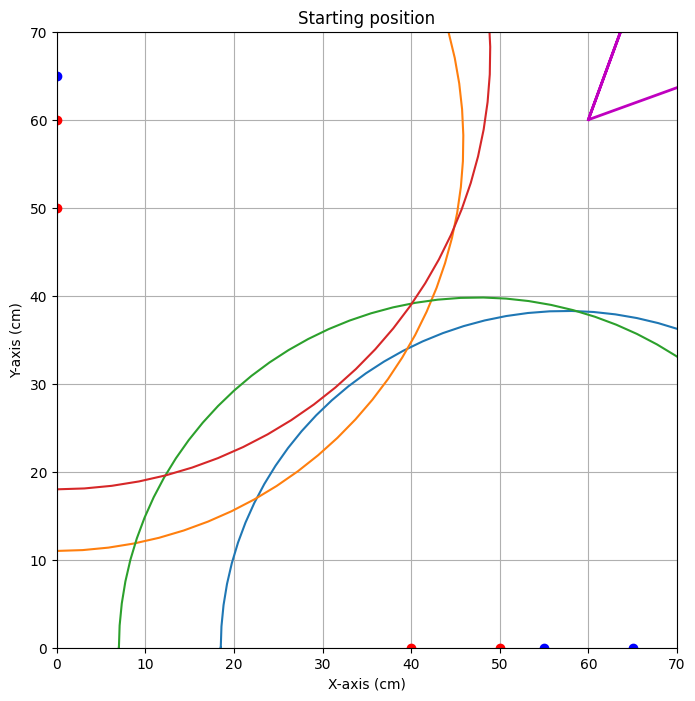


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=39.252


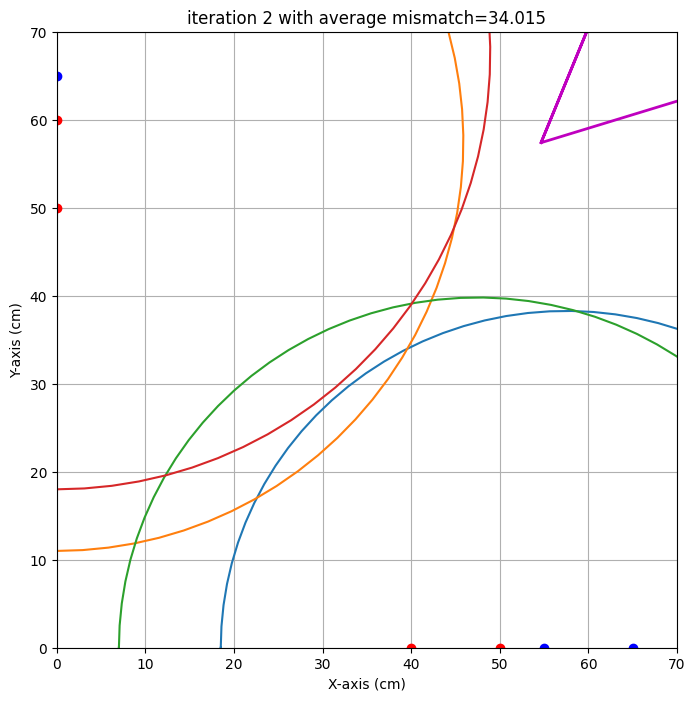

end iteration 2 with average mismatch=34.015


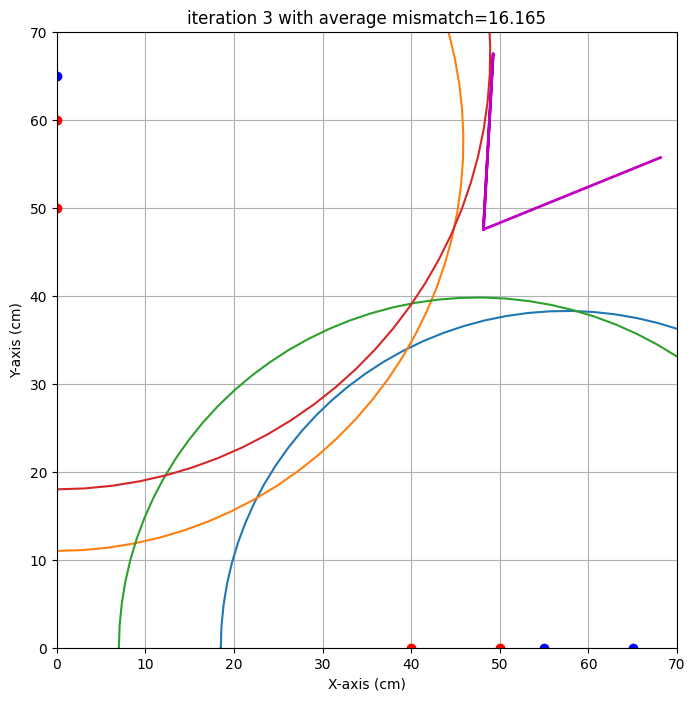

end iteration 3 with average mismatch=16.165


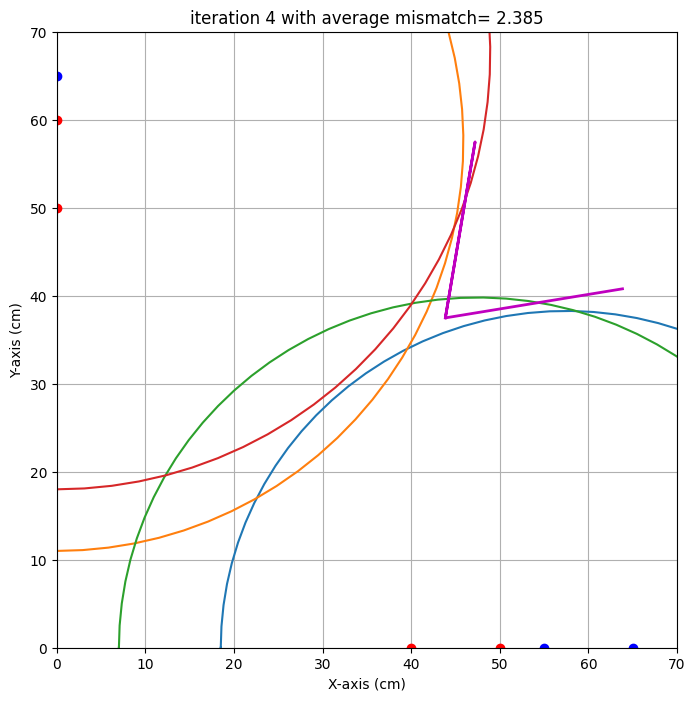

end iteration 4 with average mismatch= 2.385


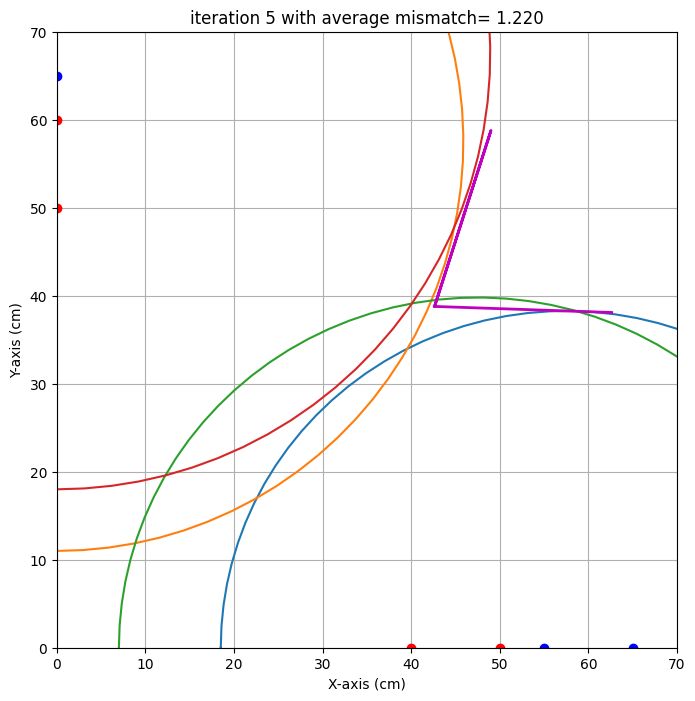

end iteration 5 with average mismatch= 1.220


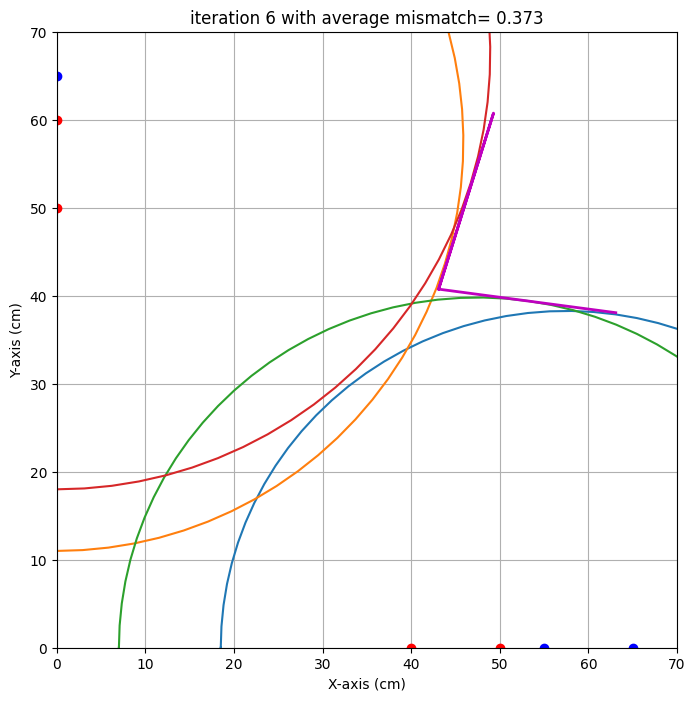

end iteration 6 with average mismatch= 0.373
end iteration 7 with average mismatch= 0.355


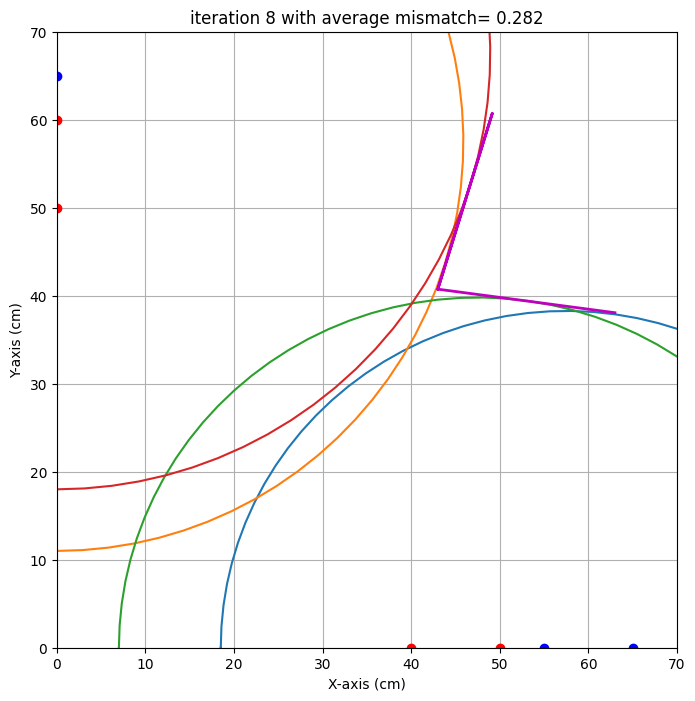

end iteration 8 with average mismatch= 0.282
end iteration 9 with average mismatch= 0.282
end iteration 10 with average mismatch= 0.282
end iteration 11 with average mismatch= 0.282
end iteration 12 with average mismatch= 0.282
end iteration 13 with average mismatch= 0.282
end iteration 14 with average mismatch= 0.282
end iteration 15 with average mismatch= 0.282
end iteration 16 with average mismatch= 0.282
end iteration 17 with average mismatch= 0.282
end iteration 18 with average mismatch= 0.282
end iteration 19 with average mismatch= 0.282
end iteration 20 with average mismatch= 0.282
end iteration 21 with average mismatch= 0.282
end iteration 22 with average mismatch= 0.282
end iteration 23 with average mismatch= 0.282
end iteration 24 with average mismatch= 0.268
end iteration 25 with average mismatch= 0.266
end iteration 26 with average mismatch= 0.265
end iteration 27 with average mismatch= 0.264
end iteration 28 with average mismatch= 0.264
end iteration 29 with average mismat

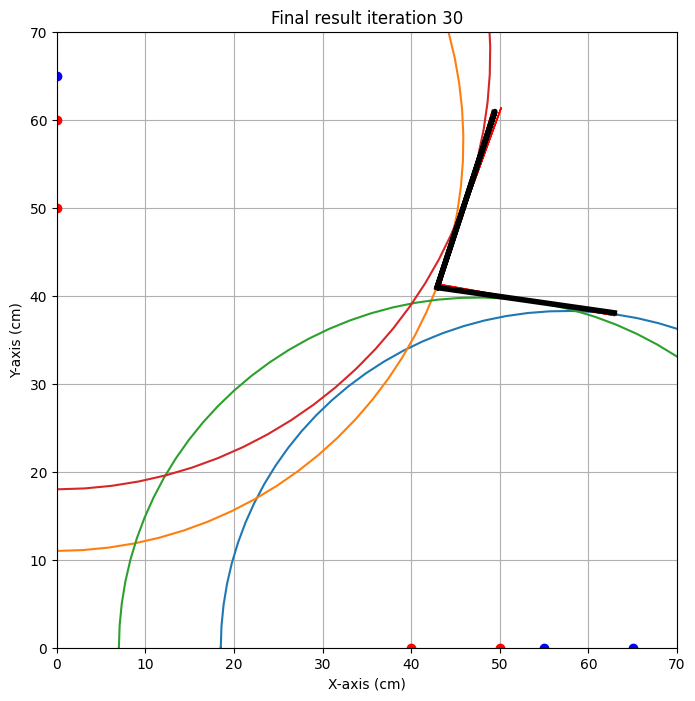

{'alpha': np.float64(-8.18160306033453), 'alpha_eps': np.float64(1.979454275276657), 'beta': np.float64(18.069061731808564), 'beta_eps': np.float64(1.8358770180116508), 'x0': np.float64(42.92173419491806), 'x0_eps': np.float64(0.3122496513277895), 'y0': np.float64(40.92971917715891), 'y0_eps': np.float64(0.4103565850540818)}
test locatie 
x0 target is : 45.6. Gevonden waarde: 42.9 cm met een standaardafwijking van 0.3 cm 
y0 target is : 41.2. Gevonden waarde: 40.9 cm met een standaardafwijking van 0.4 cm 
alpha target is : -10.0. Gevonden waarde: -8.2 graden met een standaardafwijking van 2.0 graad 
beta target is : 17.0. Gevonden waarde: 18.1 graden met een standaardafwijking van 1.8 graad 



In [32]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0'    : 45.6 ,
                    'y0'    : 41.2 ,
                    'alpha' : -10 ,
                    'beta'  : 17 
                          }
            }
           

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
#            [ 30, 0, 45, 0, 170], mis
            [ 50, 0, 65, 0, 78], 
#            [ 0, 30, 0, 45, 240], mis
            [ 0, 50, 0, 65, 93], 
            [ 40, 0, 55, 0, 81],
#            [ 0, 40, 0, 55, 240], mis\
#            [ 0, 60, 0, 75, 99] metinge opnieuw gedaan in overleg met ta
#            [ 0, 60, 0, 75, 100] na later overleg terug naar oude waardes
             [ 0, 60, 0, 75, 99]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.

#### algoritme [Bart]
1. start 

2. start met meetlocaties

eerste 4 "test locaties"
om te kijken waar hij ongeveer zit 

bron   , ontvanger
A [30, 0], [40, 0]
B [50, 0], [60, 0]
C [0, 30], [0, 40]
D [0, 50], [0, 60]

    # een meting is ongelding als deze groter dan 70cm of kleiner dan 20cm is

3. maak afhankelijk van welke metingen raakte een keuze voor de volgende metingen

	a (alle 4 raakte)
	 dit betekend dat hij ongeveer in het midden staat en er zijn in principe geen verdere metingen nodig om alles te bepalen


	b (2 raakte: 1 op elke as)
	 dit betekend dat hij in een van de 4 kwadranten zit
	doe 2 extra metingen (1 per as) en verplaats hiervoor alles met 5 richting 0
	in het geval dat een (of allebei)van deze waarde(s) niet geldig zijn verplaats je ze t.o.v hun beginposities 5 van 0 af
	nu zou je 4 goede metingen moeten hebben kan je alles bepalen 


	c (3 raken)
	 dit betekend dat hij in de buurt van een van de randen zit
	doe 1 extra meting op de as waarvan je maar een geldige metingen had en verplaats hiervoor alles met 5 richting 0
	in het geval dat deze waarde niet geldig IS verplaats je hem t.o.v zijn beginposities 5 van 0 af
	nu zou je 4 goede metingen moeten hebben kan je alles bepalen 

	d (1 raakt of 2 op dezelfde as)
	 dit betekend dat de hoek tussen het karton redelijk klein is
	 dit betekend dat hij zich bevind in een van de kolommen tussen of buiten de meetputen A,B,C,D 
	 afhankelijk van op welke as je de metingen had

	als je maar 1 raak is:
		voor de as van de waarde die wel raakte:
		doe 1 extra meting op de as waarvan je maar een geldige metingen had en verplaats hiervoor alles met 5 richting 0
		in het geval dat deze waarde niet geldig IS verplaats je hem t.o.v zijn beginposities 5 van 0 af
		nu zou je 4 goede metingen moeten hebben kan je alles bepalen


	voor de as waar je geen waardes had:
		probeer een van de volgende meetpunten afhankelijk van de as:
		x as
		[20,0],[30,0]
		[40,0],[50,0]
		[60,0],[70,0]
		y as
		[0,20],[0,30]
		[0,40],[0,50]
		[0,60],[0,70]
		
		als deze een raak is:
		doe 1 extra meting en verplaats alles met 5 richting 0
		in het geval dat deze waarde niet geldig is verplaats je hem t.o.v zijn beginposities 5 van 0 af
		nu zou je 4 goede metingen moeten hebben kan je alles bepalen

		als hij mis was:
		kies je een nieuw meetpunt tot i wel raak is

evaluatie: 
het verplaatsen van 5 bleek teweinig te zijn waardoor het pyton programma lasig onderschijd kon maken om een goede lijn te trekken en een voorgorde aangeduid voor de latere punten

Figuur: ![Alt](ideratie_1.png "Title")

evaluatie:
een afstand van 10 cm tussen de dingen bleek te klein te zijn waardoor hij in sommige gevallen niks kon meten 10 -> 15

Figuur: ![Alt](ideratie_2.png "Title")
